# Australian Rental Market Analysis

**GAO Innovation Lab Interview Submission**  
**Analyst:** Justin Hoffman  
**Date:** March 5, 2026

## Project Overview

This analysis examines which listing features are most closely associated with weekly rent in the Australian rental market. Using a dataset of about 6,800 listings, I built a predictive model to measure how much variation in rent can be explained by property size, location, and amenities, and to identify which features carry the most signal.

## The Analytical Approach

Because the dataset includes weekly rent for each listing, supervised learning was a good fit for this analysis. It let me estimate which features are associated with higher or lower rent and how strongly they relate to price.

This project also gave me a chance to apply concepts from **CS 441: Applied Machine Learning** 
at UIUC, which I'm currently taking.

Related coursework: 
- [UIUC Regression notebook](https://github.com/jhffmn82/gao-rental-project-support/blob/418ae201859874504b7bbb4f1be8a9a77353e811/Regression.ipynb)
- [UIUC GLMnet notebook](https://github.com/jhffmn82/gao-rental-project-support/blob/418ae201859874504b7bbb4f1be8a9a77353e811/GLMnet.ipynb)

## Modeling Choices

I used Ridge and Lasso regression, both regularized linear models implemented in scikit-learn.

Linear models were a good fit here for two reasons. First, they are interpretable: each coefficient shows how a feature is associated with rent while holding the other modeled features fixed, which matters in a policy context. Second, converting postcodes to dummy variables creates over 1,000 predictors, which can make ordinary least squares less stable. Regularization helps by shrinking coefficients toward zero.

The difference between the two is straightforward. Ridge shrinks all coefficients but keeps every predictor, which is useful when location signal is spread across many postcodes. Lasso can shrink some coefficients all the way to zero, making it useful when only a subset of features appears to add meaningful predictive value.

The regularization strength (alpha) was tuned using 5-fold cross-validation, minimizing MAE on log-transformed rent. Final performance was evaluated on a held-out test set (25% of the data, stratified by state) using both log-scale metrics (MAE_log, R2_log) and original-rent metrics (MAE_rent, R2_rent).

## Why Log-Transform Rent?

Rent is right-skewed, most listings cluster between $500-$900/week but a handful go up 
to $5,000. Without transformation, those expensive listings would have outsized influence 
on the model. Applying log(1 + rent) compresses the upper tail and makes prediction errors 
more comparable across cheap and expensive properties.

## Tools

| Tool | Purpose |
|---|---|
| pandas / numpy | Data loading, cleaning, feature engineering |
| scikit-learn | Ridge, Lasso, cross-validation |
| matplotlib | All visualizations |
| scipy.stats | Additional statistical testing used in H5 |
| Kaggle | Dataset source and notebook environment |

## Execution

The analysis builds the predictive model incrementally across five hypotheses, with each stage motivated by the previous one:

### 1. Data Load

The dataset was loaded from Kaggle and inspected for structure, column types, and basic shape before any cleaning or modeling was performed.

### 2. Data Quality Check

Before modeling, I reviewed the dataset for anything that could affect the analysis. 

Key checks included:
- **Missing values:** Only amenities had nulls (318 rows, 4.7%). All core modeling fields were complete.
- **Duplicates:** Found and removed 1 exact duplicate row.
- **Numeric outliers:** Used Z+3 to flag implausible values in bedrooms, bathrooms, and parking, then reviewed each flagged listing manually before deciding what to remove.
- **Postcode / state consistency:** Verified postcodes matched their assigned state using official Australia Post ranges. Zero mismatches found.
- **Redundant fields:** Suburb and locality were identical on every row. Locality was dropped.
- **High-cardinality identifiers:** Street address, title, description, and agency name are essentially unique per listing and were excluded from modeling.
- **Target variable:** price_display is right-skewed, motivating the log transformation described above.
  
### 3. Data Cleaning

Based on the quality check, the following changes were made to the dataset:

- Removed 1 duplicate row and 9 listings with implausible numeric values (e.g. a studio 
  listed with 10 bedrooms)
- Filled 318 missing amenity values with empty strings
- Dropped locality (identical to suburb), street address, title, description, and agency name
- Log-transformed rent to address right skew

The cleaned dataset contains **6,757 listings** ready for modeling.

### 4. Exploratory Data Analysis

Before modeling, I built a few visualizations to understand the data and guide decisions:

- **Rent distribution:** Confirmed the right skew and validated the log transformation
- **Rent by bedrooms and bathrooms:** Clear positive relationship, motivating H1
- **Rent by state:** Substantial price variation across states, motivating H2
- **Rent by amenity:** First look at which amenities appear associated with higher rent 
  before any controls, motivating H3 and H4
- **Amenity count distribution:** Showed how feature-rich listings vary across the dataset, 
  motivating the richness adjustment in H5

### 5. Hypothesis

I built the model in stages, with each step testing whether a new group of variables 
improved predictive performance:

| Hypothesis | Question |
|---|---|
| H1: Fundamentals | How much variation in rent can be explained by bedrooms, bathrooms, parking, and property type alone? |
| H2: Location | Does adding location improve predictions beyond property fundamentals? |
| H3: Amenities | Do individual amenities improve predictions beyond fundamentals and location? |
| H4: Amenity Effects | Which amenities are associated with higher or lower rent after controlling for fundamentals and location? |
| H5: Amenity Richness | Does overall amenity count explain part of what appears to be the effect of individual amenities? |

### 6. Iterative Model Development

Each stage adds a new feature group and is evaluated on a held-out test set using R2_log and MAE_log. Ridge and Lasso are compared at each stage, with `alpha` tuned by 5-fold cross-validation.

| Stage | Features Added | Ridge R2_log | Key Finding |
|---|---|---:|---|
| H1: Fundamentals | Bedrooms, bathrooms, parking, property type | 0.358 | Structural features capture some variation in rent, but predictive power is limited |
| H2: Location | State, postcode | 0.644 | Adding location substantially improves predictive performance |
| H3: Amenities | Individual amenity dummies | 0.660 | Amenities add a modest but consistent improvement |
| H4: Amenity Effects | Lasso coefficients on amenities | — | Pools, decks, and furnished listings show the strongest positive associations |
| H5: Amenity Richness | Amenity count added | 0.660 | In the fitted model, each additional amenity is associated with about a 0.87% increase in predicted rent

### 7. Summary

The analysis suggests three broad patterns in the dataset:

1. **Location adds the most predictive value.** Adding postcode and state increased R2_log from 0.358 to 0.644, the largest improvement in the modeling sequence.
2. **Property fundamentals still matter.** Bedrooms, bathrooms, and parking explain a meaningful share of variation in rent on their own, though some of that predictive value overlaps with location.
3. **Amenities add a smaller amount of signal.** Individual amenities improved R2_log from 0.644 to 0.660. Pools, decks, and furnished listings showed some of the strongest positive associations in the fitted model. Part of the apparent amenity effect may reflect feature-rich properties in already expensive areas.

The final H5 Ridge model achieved **R2_log = 0.660** and **MAE_rent = 112 AUD/week**, explaining about 66% of the variation in log rent on the test set. Performance is strongest towards the mean and weaker for high price rentals. This is consistent with optimizing on log-scale errors and compressing the right tail of the rent distribution.

### 8. Next Steps

**Geographic Clustering (Low effort, High value)**  
Replace 1,093 postcode dummies and 8 state dummies with 20-50 geographic clusters derived 
from latitude and longitude using K-means. Each listing gets assigned to a numbered cluster, 
which is one-hot encoded like any other categorical variable. This reduces the feature space 
dramatically, handles sparse postcodes, and would likely improve model performance. The 
clustering itself is a few lines of sklearn. A heatmap of average predicted rent by cluster 
plotted on a map of Australia would be a compelling visualization, though that requires a 
mapping library, making the visual moderate effort relative to the 
model change.

**Residual Language Analysis (Low effort, Low value)**
Apply TF-IDF to listing descriptions and compute an impact score for each word as
sum(weight^2 × residual) across all listings. Words with high positive scores would appear more often in listings that rent for more than the model predicts, while negative scores would indicate the opposite. Squaring the TF-IDF weight emphasizes more distinctive words and reduces low-weight noise. A word cloud colored by impact direction could make the results easy to scan, but the main value would likely be exploratory or visual rather than adding a major new modeling insight.

**Nonlinear Amenity Sensitivity Check (Moderate effort, High value)**
Fit a nonlinear model better suited to raw rent and the upper tail of the market, then use it to rescore the test set after selected amenities are toggled on and off. For listings that do not have a chosen amenity, add it and measure the predicted change in rent; for listings that do have it, remove it and measure the drop. This would provide a model-based sanity check on whether the amenity signals from the linear models remain directionally consistent once nonlinear effects and interactions are allowed. The main value is in testing amenity signal where the current log-linear model fits less well, especially in higher-rent listings. The main overhead is fitting and tuning the nonlinear model and then summarizing the predicted changes in a way that is easy to compare across low-, mid-, and high-rent segments.

In [1]:
import warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

## 1. Data Loading

Begin by locating and loading the dataset from the Kaggle input directory.
A quick shape and column check confirms the data loaded correctly before 
any analysis begins.

In [2]:
DATA_PATH = "/kaggle/input/datasets/kanchana1990/australian-rental-market-data-2026/australian_rental_market_2026.csv"
df = pd.read_csv(DATA_PATH)

rows, cols = df.shape
print(f"Loaded {rows} rows and {cols} columns")
print("\nColumns:")
print(df.columns.tolist())

Loaded 6767 rows and 16 columns

Columns:
['title', 'price_display', 'description', 'propertyType', 'locality', 'latitude', 'longitude', 'postcode', 'state', 'street_address', 'suburb', 'bathrooms', 'bedrooms', 'parking_spaces', 'agency_name', 'amenities']


## 2. Data Quality Assessment

Before modeling I reviewed the dataset for anything that could cause problems downstream. 
The key questions were:

- Are any important fields missing values?
- Are there duplicate listings?
- Do numeric fields contain implausible values?
- Are postcodes consistent with their assigned state?
- Is the target variable skewed?
- Are any fields redundant or near-unique per listing?

In [3]:
# List missing values
missing_info = []

for col in df.columns:
    missing_count = df[col].isna().sum()
    missing_pct = round((missing_count / len(df)) * 100, 2)

    missing_info.append({"column": col, "missing_count": missing_count, "missing_pct": missing_pct })

missing_summary = pd.DataFrame(missing_info)
missing_summary = missing_summary.sort_values(by="missing_count", ascending=False)

print("Missing values by column:")
display(missing_summary[missing_summary["missing_count"] > 0])

Missing values by column:


,column,missing_count,missing_pct
15,amenities,318,4.7


In [4]:
# Duplicates
dup_count = df.duplicated().sum()
print(f"\nDuplicate rows: {dup_count}")


Duplicate rows: 1


In [5]:
# Numeric Summary
numeric_df = df.select_dtypes(include=[np.number])
numeric_summary = numeric_df.describe().transpose()

print("\nNumeric summary:")
display(numeric_summary)



Numeric summary:


,count,mean,std,min,25%,50%,75%,max
price_display,6767.0,733.763558,333.458540,100.000000,550.000000,670.000000,800.000000,5000.000000
latitude,6767.0,-33.356418,3.715287,-42.901233,-34.978698,-33.771662,-32.068947,-12.354202
longitude,6767.0,143.292707,12.322636,114.608100,138.817147,149.181219,150.966123,153.633677
postcode,6767.0,3696.632186,1424.513815,800.000000,2614.000000,3068.000000,5023.000000,7325.000000
bathrooms,6767.0,1.568346,0.674056,1.000000,1.000000,1.000000,2.000000,12.000000
bedrooms,6767.0,2.815132,1.084225,1.000000,2.000000,3.000000,4.000000,14.000000
parking_spaces,6767.0,1.733560,0.873681,1.000000,1.000000,2.000000,2.000000,14.000000


In [6]:
# Cardinality of attributes
print("\nNumber of unique values by column:")

unique_counts = df.nunique(dropna=False)
unique_counts = unique_counts.sort_values(ascending=False)
unique_summary = unique_counts.to_frame(name="nunique")

display(unique_summary)


Number of unique values by column:


,nunique
street_address,6752
description,6735
title,6525
longitude,6521
latitude,6521
amenities,3350
agency_name,2943
locality,1997
suburb,1997
postcode,1093


## Outlier Check

Listings with unusually large numeric values were flagged and reviewed manually before modeling.

In [7]:
# Numeric columns to check for unusual values
numeric_fields = ['bedrooms', 'bathrooms', 'parking_spaces', 'price_display']

# Columns to show when reviewing flagged rows
display_cols = ['bedrooms', 'bathrooms', 'parking_spaces', 
                'price_display','state', 'postcode', 'propertyType', 'amenities']

# Keep track of all unique flagged row indices
outlier_indices = set()

# Check one numeric column at a time
for col in numeric_fields:
    
    # Compute the absolute z-score for every row in this column
    z_scores = np.abs(stats.zscore(df[col]))
    
    # Store the row numbers flagged for this column
    flagged_rows = []
    
    # Look through the z-scores one row at a time
    for i in range(len(df)):
        
        # Flag values more than 3 standard deviations from the mean
        if z_scores[i] > 3:
            flagged_rows.append(i)
            outlier_indices.add(i)
    
    # If any rows were flagged, show them for manual review
    if len(flagged_rows) > 0:
        print(f"\n--- {col}: {len(flagged_rows)} flagged (showing top 10) ---")
        
        # Pull just the flagged rows into a new dataframe
        flagged_df = df.iloc[flagged_rows]
        
        # Sort so the largest values in that column appear first
        flagged_df = flagged_df.sort_values(by=col, ascending=False)
        
        # Display only the review columns
        display(flagged_df[display_cols].head(10))

# Print the total number of unique flagged listings
print(f"\nTotal unique listings flagged: {len(outlier_indices)}")


--- bedrooms: 9 flagged (showing top 10) ---


,bedrooms,bathrooms,parking_spaces,price_display,state,postcode,propertyType,amenities
2543,14,5,2,340.0,Vic,3051,house,"Reverse-cycle Air Conditioning, Toilets: 3, Fu..."
6759,11,12,5,3800.0,NSW,2770,house,"Courtyard, Garage: 1, Open Spaces: 4, Secure P..."
6745,10,10,4,3500.0,NSW,2749,house,"Deck, Open Spaces: 4, Outdoor Entertaining Are..."
6724,10,10,5,3950.0,NSW,2760,studio,Open Spaces: 5
6728,10,10,5,3950.0,NSW,2760,house,Open Spaces: 5
2406,8,8,2,300.0,Tas,7310,house,"Secure Parking, Air Conditioning, Built-in War..."
1526,7,2,3,2200.0,NSW,2000,apartment,"Balcony, Courtyard, Garage: 3, Secure Parking,..."
5863,7,5,2,950.0,NSW,2765,house,"Balcony, Courtyard, Fully Fenced, Garage: 2, R..."
2287,7,3,4,1800.0,NSW,2200,house,"Balcony, Fully Fenced, Garage: 2, Open Spaces:..."



--- bathrooms: 62 flagged (showing top 10) ---


,bedrooms,bathrooms,parking_spaces,price_display,state,postcode,propertyType,amenities
6759,11,12,5,3800.0,NSW,2770,house,"Courtyard, Garage: 1, Open Spaces: 4, Secure P..."
6745,10,10,4,3500.0,NSW,2749,house,"Deck, Open Spaces: 4, Outdoor Entertaining Are..."
6728,10,10,5,3950.0,NSW,2760,house,Open Spaces: 5
6724,10,10,5,3950.0,NSW,2760,studio,Open Spaces: 5
2406,8,8,2,300.0,Tas,7310,house,"Secure Parking, Air Conditioning, Built-in War..."
80,5,5,6,4000.0,Vic,3944,house,"Carport: 2, Garage: 2, Open Spaces: 2, Secure ..."
3109,6,5,2,2000.0,NSW,2219,duplex/semi-detached,"Open Spaces: 2, Swimming Pool - Inground, Air ..."
2781,5,5,2,2500.0,NSW,2071,house,"Garage: 2, Secure Parking, Swimming Pool - Ing..."
5863,7,5,2,950.0,NSW,2765,house,"Balcony, Courtyard, Fully Fenced, Garage: 2, R..."
6001,5,5,2,1200.0,NSW,2765,house,Garage: 2



--- parking_spaces: 83 flagged (showing top 10) ---


,bedrooms,bathrooms,parking_spaces,price_display,state,postcode,propertyType,amenities
1735,2,2,14,730.0,Qld,4215,apartment,"Balcony, Fully Fenced, Garage: 2, Open Spaces:..."
62,5,2,10,1650.0,Qld,4118,house,"Garage: 10, Swimming Pool - Inground, Air Cond..."
2994,3,2,10,950.0,Qld,4103,house,"Garage: 10, Split-system Air Conditioning, Pet..."
2706,4,4,10,560.0,Vic,3860,house,Garage: 10
3260,3,1,9,900.0,Qld,4125,acreage/semi-rural,"Garage: 9, Pets Allowed"
1480,2,1,9,430.0,Vic,3956,house,"Deck, Fully Fenced, Garage: 3, Open Spaces: 6,..."
2265,3,1,8,680.0,Qld,4740,house,Garage: 8
3732,3,2,8,1100.0,SA,5152,house,"Carport: 1, Garage: 3, Open Spaces: 4, Shed, S..."
2280,5,2,8,700.0,Vic,3753,acreage/semi-rural,"Deck, Fully Fenced, Garage: 2, Open Spaces: 6,..."
6510,4,2,8,950.0,NSW,2146,house,"Garage: 3, Open Spaces: 5"



--- price_display: 114 flagged (showing top 10) ---


,bedrooms,bathrooms,parking_spaces,price_display,state,postcode,propertyType,amenities
2032,3,2,3,5000.0,NSW,2481,house,"Open Spaces: 3, Air Conditioning, Furnished"
3026,3,2,2,4900.0,NSW,2027,apartment,Garage: 2
51,3,2,1,4500.0,NSW,2028,house,"Carport: 1, Ensuite: 1"
1093,4,3,2,4500.0,NSW,2025,house,Open Spaces: 2
80,5,5,6,4000.0,Vic,3944,house,"Carport: 2, Garage: 2, Open Spaces: 2, Secure ..."
637,3,2,2,3950.0,NSW,2089,apartment,Garage: 2
6728,10,10,5,3950.0,NSW,2760,house,Open Spaces: 5
6724,10,10,5,3950.0,NSW,2760,studio,Open Spaces: 5
1498,4,3,2,3850.0,NSW,2108,house,"Garage: 2, Air Conditioning, Alarm System, Bui..."
6759,11,12,5,3800.0,NSW,2770,house,"Courtyard, Garage: 1, Open Spaces: 4, Secure P..."



Total unique listings flagged: 227


## Postcode / State Consistency Check

Australian postcodes follow well-defined numeric ranges by state and territory.
Listings where the postcode does not match the assigned state were flagged as
likely data entry errors and removed before modeling.

Postcode ranges sourced from:
[Australia Post Postcodes Turn 50](https://collectables.auspost.com.au/community-and-events/articles/postcodes-turn-50)

In [8]:
# Valid postcode ranges for each Australian state / territory
postcode_ranges = {
    'NSW': [(1000, 2599), (2619, 2899), (2921, 2999)],
    'ACT': [(200, 299), (2600, 2618), (2900, 2920)],
    'VIC': [(3000, 3999), (8000, 8999)],
    'QLD': [(4000, 4999), (9000, 9999)],
    'SA':  [(5000, 5999)],
    'WA':  [(6000, 6999)],
    'TAS': [(7000, 7999)],
    'NT':  [(800, 899), (900, 999)],
}

# Keep track of which rows do not match
mismatch_count = 0

# Check each row one at a time
for i in range(len(df)):
    
    # Read the postcode and state from this row
    postcode = int(df.iloc[i]['postcode'])
    state = str(df.iloc[i]['state']).strip().upper()
    
    # Assume it does not match until proven otherwise
    matches = False
    
    # Look at all valid postcode ranges for this state
    if state in postcode_ranges:
        for lo, hi in postcode_ranges[state]:
            if lo <= postcode <= hi:
                matches = True
                break
    
    # Count rows that do not match any valid range
    if not matches:
        mismatch_count += 1

print(f"Mismatched listings: {mismatch_count}")

Mismatched listings: 0


## Suburb / Locality Consistency Check

The dataset contains two fields representing neighborhood-level geography: `suburb` and `locality`.
These were compared row by row to determine whether they contained the same information.

In [9]:
# Check whether suburb and locality are the same on every row

# Start by assuming they match everywhere
mismatch_count = 0

# Save the row numbers where they do not match
mismatch_rows = []

# Check each row one at a time
for i in range(len(df)):
    
    suburb = str(df.iloc[i]['suburb']).strip()
    locality = str(df.iloc[i]['locality']).strip()
    
    if suburb != locality:
        mismatch_count += 1
        mismatch_rows.append(i)

# If there are no mismatches, then the fields match on all rows
exact_match = (mismatch_count == 0)

print(f"Exact match on all rows: {exact_match}")
print(f"Mismatched rows: {mismatch_count}")

# Show a few examples if any mismatches were found
if mismatch_count > 0:
    display(df.iloc[mismatch_rows][['suburb', 'locality', 'postcode', 'state']].head(20))

Exact match on all rows: True
Mismatched rows: 0


## Data Quality Summary

The raw dataset contained **6,768 listings**. Issues identified:

- **Missing values:** Only amenities had nulls, 318 rows (4.7%). All core modeling fields 
  were complete. Missing amenities treated as empty strings.
- **Duplicates:** 1 exact duplicate row detected and removed.
- **Numeric outliers:** Z+3 flagged 227 listings, but the threshold was too sensitive for 
  bathrooms and parking given their tight distributions. Manual review led to domain-specific 
  cutoffs instead, removing 9 listings with clearly implausible values, including a studio 
  listed with 10 bedrooms.
- **Postcode / state consistency:** 0 mismatches found after normalizing state casing.
- **Redundant fields:** suburb and locality were identical on every row. locality dropped, 
  suburb retained.
- **High-cardinality identifiers:** street_address, title, description, and agency_name are 
  near-unique per listing and excluded from modeling.
- **Target variable:** price_display is right-skewed (median 670 AUD, max 5,000 AUD) 
  and will be log-transformed.

## 3. Data Cleaning

The following steps were applied to prepare the dataset for modeling:

- Removed 1 duplicate row and 9 listings with implausible numeric values
- Filled 318 missing amenity values with empty strings
- Dropped locality (identical to suburb), street address, title, description, and agency name
- Log-transformed rent to address right skew

**On the outlier cutoffs:** Z+3 flagged 227 listings but proved too aggressive, with a mean 
of 1.6 bathrooms, Z+3 kicks in at just 3.6, which is a perfectly normal property. Manual 
review led to domain-specific cutoffs instead:

| Field | Flagged (Z>3) | Cutoff Applied | Rationale |
|---|---:|---|---|
| bedrooms | 9 | > 8 | Confirmed data errors; one studio listed with 10 bedrooms |
| bathrooms | 62 | > 7 | Z+3 too sensitive given tight distribution |
| parking_spaces | 83 | > 9 | Garage: 10 entries appear to be data entry errors |
| price_display | 114 | none | High-rent listings are plausible; log transform reduces their influence |

In [10]:
# Remove clearly implausible numeric values based on manual review

rows_to_keep = []

for i in range(len(df)):
    
    bedrooms = df.iloc[i]["bedrooms"]
    bathrooms = df.iloc[i]["bathrooms"]
    parking = df.iloc[i]["parking_spaces"]
    
    # Keep the row unless one of the values is clearly too large
    if bedrooms > 8 or bathrooms > 7 or parking > 9:
        continue
    
    rows_to_keep.append(i)

print(f"Outlier listings removed: {len(df) - len(rows_to_keep)}")

df = df.iloc[rows_to_keep].reset_index(drop=True)
print(f"Shape after removing outliers: {df.shape}")

# Fill missing amenities with an empty string
df["amenities"] = df["amenities"].fillna("").astype(str)

# Create a log-transformed version of weekly rent
df["log_price"] = np.log1p(df["price_display"])

# Drop columns that are close to unique identifiers and not useful for this model
columns_to_drop = [
    "street_address",
    "title",
    "description",
    "locality",
    "agency_name"
]

df = df.drop(columns=columns_to_drop)
print(f"Shape after dropping identifier columns: {df.shape}")

Outlier listings removed: 10
Shape after removing outliers: (6757, 16)
Shape after dropping identifier columns: (6757, 12)


## 4. Exploratory Data Analysis

Before modeling, I built a few visualizations to understand the data and motivate the 
feature groups used in the models that follow:

- **Rent distribution:** Confirmed right skew and validated the log transformation
- **Rent by bedrooms and bathrooms:** Clear positive relationship with rent, motivating H1
- **Rent by state:** Substantial price variation across states, motivating H2
- **Rent by amenity (unadjusted):** First look at which amenities appear associated with 
  higher rent before any controls are added, motivating H3 and H4
- **Amenity count distribution:** Showed how amenity richness varies across listings, 
  motivating the richness adjustment in H5

### 4.1 Rent Distribution: Raw vs Log-Transformed

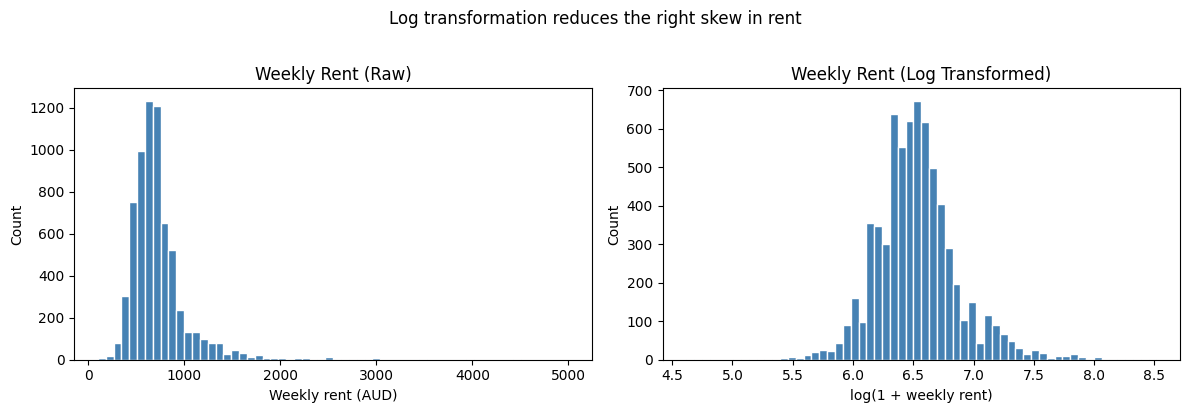

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["price_display"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Weekly Rent (Raw)")
axes[0].set_xlabel("Weekly rent (AUD)")
axes[0].set_ylabel("Count")

axes[1].hist(df["log_price"], bins=60, color="steelblue", edgecolor="white")
axes[1].set_title("Weekly Rent (Log Transformed)")
axes[1].set_xlabel("log(1 + weekly rent)")
axes[1].set_ylabel("Count")

plt.suptitle("Log transformation reduces the right skew in rent", y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Rent by Property Size

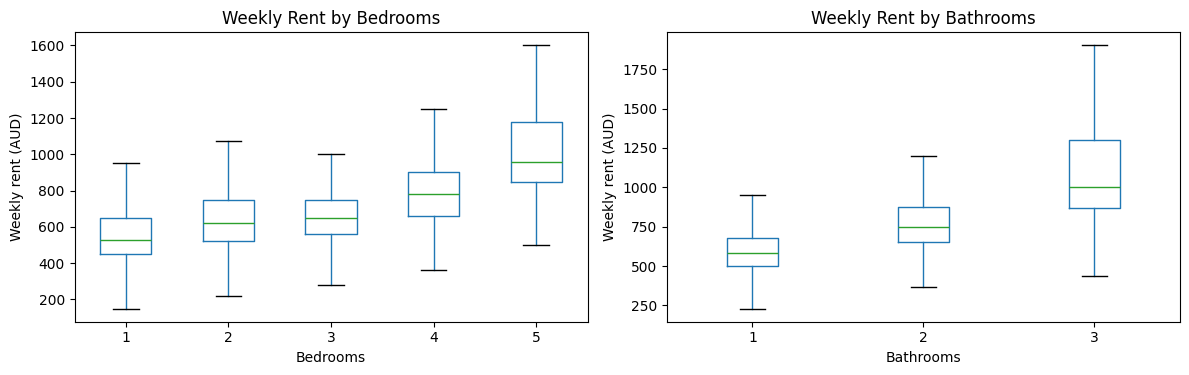

In [12]:
# Limit br / ba to Z = +2
plot_df = df[(df["bedrooms"] <= 5) & (df["bathrooms"] <= 3)].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_df.boxplot(column="price_display", by="bedrooms", ax=axes[0], grid=False, showfliers=False)
plot_df.boxplot(column="price_display", by="bathrooms", ax=axes[1], grid=False, showfliers=False)

axes[0].set_title("Weekly Rent by Bedrooms")
axes[0].set_xlabel("Bedrooms")
axes[0].set_ylabel("Weekly rent (AUD)")

axes[1].set_title("Weekly Rent by Bathrooms")
axes[1].set_xlabel("Bathrooms")
axes[1].set_ylabel("Weekly rent (AUD)")

fig.suptitle("")
plt.tight_layout()
plt.show()

### 4.3 Rent by State

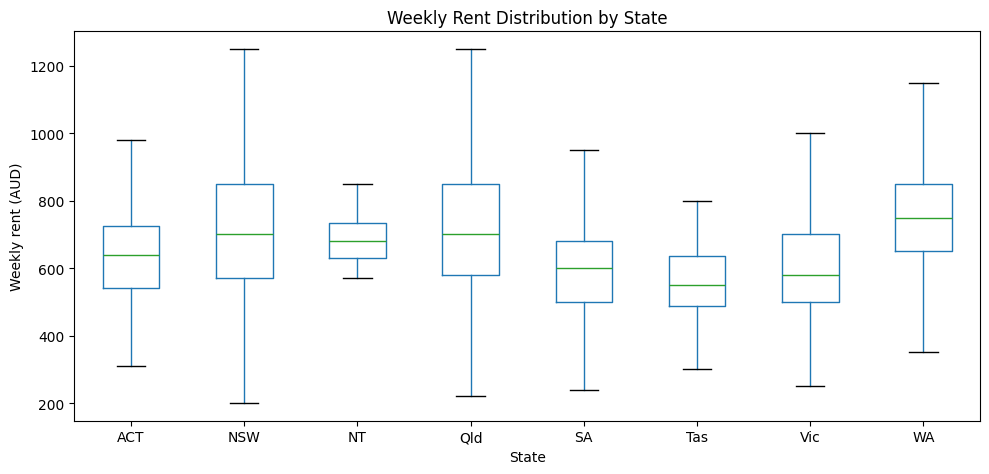

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

df.boxplot(column="price_display", by="state", ax=ax, grid=False, showfliers=False)

ax.set_title("Weekly Rent Distribution by State")
ax.set_xlabel("State")
ax.set_ylabel("Weekly rent (AUD)")

plt.suptitle("")
plt.tight_layout()
plt.show()

### 4.4 Rent by Amenity (Unadjusted)

This chart shows simple average rent differences by amenity. These are raw comparisons only. For example, listings with a pool may also be larger or located in more expensive areas. Later models control for size and location to see whether specific amenities still appear to matter after accounting for those factors.

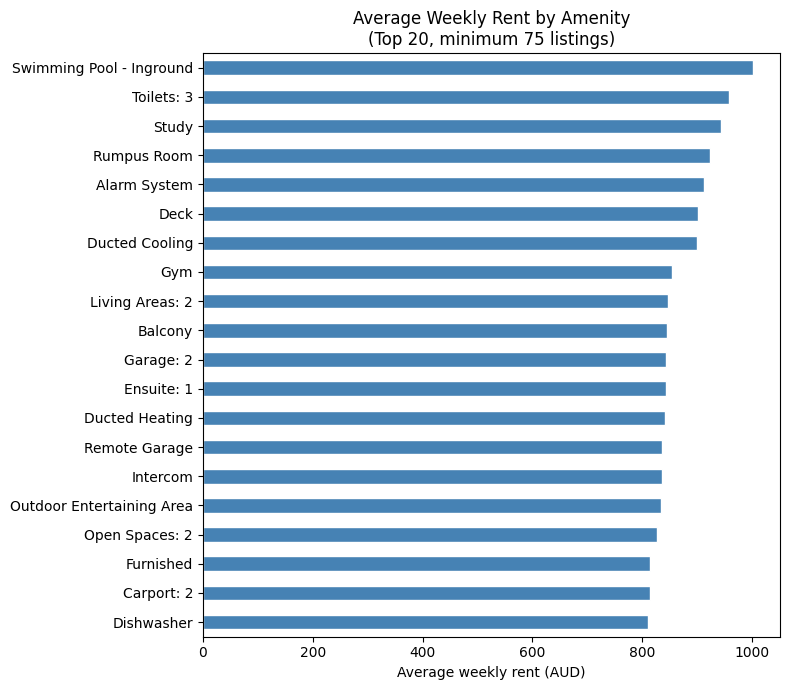

In [14]:
# Split the amenities string into a list for each listing
amenity_lists = df["amenities"].str.split(",")

# Build a simple table of (amenity, rent) pairs
rows = []

for i in range(len(df)):
    
    rent = df.loc[i, "price_display"]
    amenities = amenity_lists.iloc[i]

    for amenity in amenities:
        amenity = amenity.strip()

        # Skip blank entries
        if amenity != "":
            rows.append([amenity, rent])

amenity_df = pd.DataFrame(rows, columns=["amenity", "price_display"])

# Only keep amenities that appear often enough to be meaningful
min_count = 75

amenity_stats = []

# Go through each amenity one at a time
for amenity in amenity_df["amenity"].unique():
    
    rows_for_amenity = amenity_df[amenity_df["amenity"] == amenity]
    count = len(rows_for_amenity)

    # Compute average rent only if the amenity appears enough times
    if count >= min_count:
        avg_rent = rows_for_amenity["price_display"].mean()
        amenity_stats.append([amenity, count, avg_rent])

amenity_summary = pd.DataFrame(
    amenity_stats,
    columns=["amenity", "count", "avg_rent"]
)

# Sort by average rent and keep the top 20 amenities
amenity_summary = amenity_summary.sort_values(by="avg_rent", ascending=False)
amenity_summary = amenity_summary.head(20)

# Plot the top 20 amenities by average weekly rent
fig, ax = plt.subplots(figsize=(8, 7))

amenity_summary.sort_values(by="avg_rent").plot(
    kind="barh",
    x="amenity",
    y="avg_rent",
    color="steelblue",
    edgecolor="white",
    ax=ax,
    legend=False
)

ax.set_title(f"Average Weekly Rent by Amenity\n(Top 20, minimum {min_count} listings)")
ax.set_xlabel("Average weekly rent (AUD)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### 4.5 Distribution of Amenity Counts

Before incorporating amenity richness into the model, it is helpful to understand how many amenities listings typically contain. The chart below shows the distribution of amenity_count, defined as the total number of amenities listed for each property.

This provides context for later analysis in H5, where amenity_count is introduced as a variable capturing the general richness of a listing. Properties with more amenities may command higher rents simply because they are more fully featured overall, rather than because of any single amenity.

Understanding this distribution helps interpret the results of the H5 model, which separates the general premium associated with feature-rich listings from the effects of specific amenities.

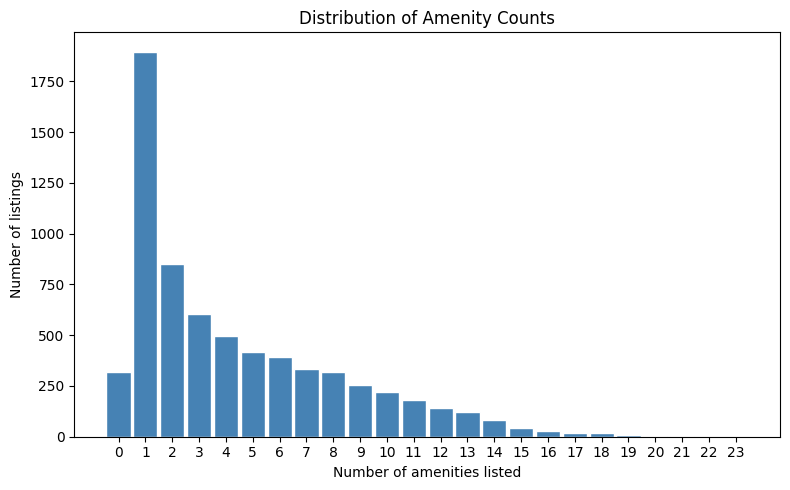

In [15]:
# 4.5 Distribution of amenity counts

amenity_lists = df["amenities"].str.split(",")

amenity_counts = []

# Count number of amenities per listing
for i in range(len(df)):
    amenities = amenity_lists.iloc[i]
    count = 0

    for amenity in amenities:
        amenity = amenity.strip()

        if amenity != "":
            count += 1

    amenity_counts.append(count)

# Plot histogram
max_count = max(amenity_counts)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(amenity_counts,bins=range(0, max_count + 2),align="left",color="steelblue",edgecolor="white",rwidth=0.9)

ax.set_title("Distribution of Amenity Counts")
ax.set_xlabel("Number of amenities listed")
ax.set_ylabel("Number of listings")
ax.set_xticks(range(0, max_count + 1))

plt.tight_layout()
plt.show()

## 5. Hypotheses

I built the model in stages, with each step testing whether a new group of variables 
improves predictive performance on a test set.

**H1: Property fundamentals explain much of rent variation**
Baseline model using bedrooms, bathrooms, parking, and property type only.

**H2: Location adds important information**
Same properties can rent for very different prices depending on where they are. State 
and postcode are added to test how much location improves predictions.

**H3: Amenities improve the model further**
Amenity text is tokenized into individual dummy variables and added to test whether 
features like pools or air conditioning improve performance beyond size and location.

**H4: Which amenities are associated with higher rent?**
Lasso is used to identify which specific amenities retain meaningful coefficients after 
controlling for fundamentals and location, shrinking unimportant ones to zero.

**H5: Amenity richness adjustment**
An amenity_count variable is added to separate the general premium for feature-rich 
listings from the distinct effects of individual amenities.

## 6. Modeling

### H1: Fundamentals

The baseline model uses only bedrooms, bathrooms, parking spaces, and property type, with no location or amenity variables. This provides a starting point for measuring how much variation in rent can be captured by structural features alone.

Ridge and Lasso are both tested with `alpha` tuned by 5-fold cross-validation. I expect bedrooms, bathrooms, and parking to be positively associated with rent, but overall performance to remain limited without location information.

### Cross-Validated Model Fitting

The same fitting function is used at every stage (H1–H5) to ensure consistent tuning. 
For each candidate alpha, the training data is split into 5 folds, the model trains on 
4 and validates on the remaining 1, rotating until every fold has been used. The alpha 
with the lowest average MAE across folds is selected, then the model is refit on the 
full training set and evaluated once on the held-out test set.

In [16]:
# Fit a Ridge or Lasso model and use k-fold cross-validation
# to choose the alpha value with the lowest average validation MAE.
# Then refit the best model on the full training set and evaluate
# it on the held-out test set.

def fit_model_with_cv(model_type, X_train, y_train, X_test, y_test, alpha_values, kf, state_train):
    
    best_alpha = None
    best_cv_mae = None

    # Try each candidate alpha value
    for alpha in alpha_values:
        fold_maes = []

        # Run cross-validation one fold at a time
        for train_index, val_index in kf.split(X_train, state_train):
            
            # Split into fold-level train and validation sets
            X_fold_train = X_train.iloc[train_index]
            X_fold_val = X_train.iloc[val_index]
            y_fold_train = y_train.iloc[train_index]
            y_fold_val = y_train.iloc[val_index]

            # Build the requested model type
            if model_type == "ridge":
                model = Ridge(alpha=alpha)
            else:
                model = Lasso(alpha=alpha, max_iter=10000)

            # Fit on the fold training data
            model.fit(X_fold_train, y_fold_train)

            # Predict on the fold validation data
            val_predictions = model.predict(X_fold_val)

            # Measure validation error and store it
            fold_mae = mean_absolute_error(y_fold_val, val_predictions)
            fold_maes.append(fold_mae)

        # Average the validation MAE across folds
        mean_cv_mae = np.mean(fold_maes)
        print(f"{model_type.title()} alpha={alpha}: CV MAE = {mean_cv_mae:.4f}")

        # Keep the alpha with the lowest average CV MAE
        if best_cv_mae is None or mean_cv_mae < best_cv_mae:
            best_cv_mae = mean_cv_mae
            best_alpha = alpha

    # Refit the best model on the full training set
    if model_type == "ridge":
        best_model = Ridge(alpha=best_alpha)
    else:
        best_model = Lasso(alpha=best_alpha, max_iter=10000)

    best_model.fit(X_train, y_train)

    # Predict on the held-out test set
    test_predictions = best_model.predict(X_test)

    # Evaluate on the log-rent scale
    test_mae_log = mean_absolute_error(y_test, test_predictions)
    test_r2_log = r2_score(y_test, test_predictions)

    # Convert actual and predicted values back to rent scale
    y_test_rent = np.expm1(y_test)
    test_predictions_rent = np.expm1(test_predictions)

    # Evaluate on the original rent scale
    test_mae_rent = mean_absolute_error(y_test_rent, test_predictions_rent)
    test_r2_rent = r2_score(y_test_rent, test_predictions_rent)

    return best_model, best_alpha, best_cv_mae, test_mae_log, test_r2_log, test_mae_rent, test_r2_rent

In [17]:
# Features for the fundamentals model 
X = df[["bedrooms", "bathrooms", "parking_spaces","propertyType"]].copy()
# Target for the fundamentals model
y = df["log_price"].copy()

# Convert propertyType into dummy columns with 0/1 values
X = pd.get_dummies(X, columns=["propertyType"])

# Generates a training set and test set. 
# Default value of test size is used (0.25).
# Random_state is fixed for reproducibility
# Sets are stratified by state to ensure equal distribution between sets.
X_train, X_test, y_train, y_test, state_train, state_test = train_test_split(X, y, df["state"], random_state=1, stratify=df["state"])

# Candidate alpha values
alpha_values = [0.001, 0.01, 0.1, 1, 10, 100]

# 5-fold cross-validation setup
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")

Training rows: 5067
Test rows: 1690


In [18]:
# Stores final results
results = []

# Ridge regression
best_ridge_model, best_ridge_alpha, best_ridge_cv_mae, ridge_mae_log, ridge_r2_log, ridge_mae_rent, ridge_r2_rent = fit_model_with_cv(
    "ridge", X_train, y_train, X_test, y_test, alpha_values, kf, state_train)

print(f"\nBest Ridge alpha: {best_ridge_alpha}\n")
results.append(["Ridge", ridge_mae_log, ridge_r2_log, ridge_mae_rent, ridge_r2_rent])

# Lasso regression
best_lasso_model, best_lasso_alpha, best_lasso_cv_mae, lasso_mae_log, lasso_r2_log, lasso_mae_rent, lasso_r2_rent = fit_model_with_cv(
    "lasso", X_train, y_train, X_test, y_test, alpha_values, kf, state_train)

print(f"\nBest Lasso alpha: {best_lasso_alpha}\n")
results.append(["Lasso", lasso_mae_log, lasso_r2_log, lasso_mae_rent, lasso_r2_rent])

# Results table
results_df = pd.DataFrame( results, columns=["model", "MAE_log", "R2_log", "MAE_rent", "R2_rent"])
display(results_df)

Ridge alpha=0.001: CV MAE = 0.1950
Ridge alpha=0.01: CV MAE = 0.1950
Ridge alpha=0.1: CV MAE = 0.1950
Ridge alpha=1: CV MAE = 0.1950
Ridge alpha=10: CV MAE = 0.1949
Ridge alpha=100: CV MAE = 0.1951

Best Ridge alpha: 10

Lasso alpha=0.001: CV MAE = 0.1951
Lasso alpha=0.01: CV MAE = 0.1964
Lasso alpha=0.1: CV MAE = 0.2371
Lasso alpha=1: CV MAE = 0.2538
Lasso alpha=10: CV MAE = 0.2538
Lasso alpha=100: CV MAE = 0.2538

Best Lasso alpha: 0.001



,model,MAE_log,R2_log,MAE_rent,R2_rent
0,Ridge,0.202248,0.357790,162.920139,0.237295
1,Lasso,0.202435,0.356516,163.086217,0.236272


### H1 Results

Ridge and Lasso perform almost identically here, with both achieving about **R2_log = 0.358** and **MAE_rent ≈ 163 AUD/week**. Property fundamentals explain about a third of the variation in log rent, which is meaningful but still limited. Predictions are compressed toward the middle of the market, with lower-rent properties overpredicted and higher-rent properties underpredicted. This suggests that important information is still missing from the model, making location a natural next addition.

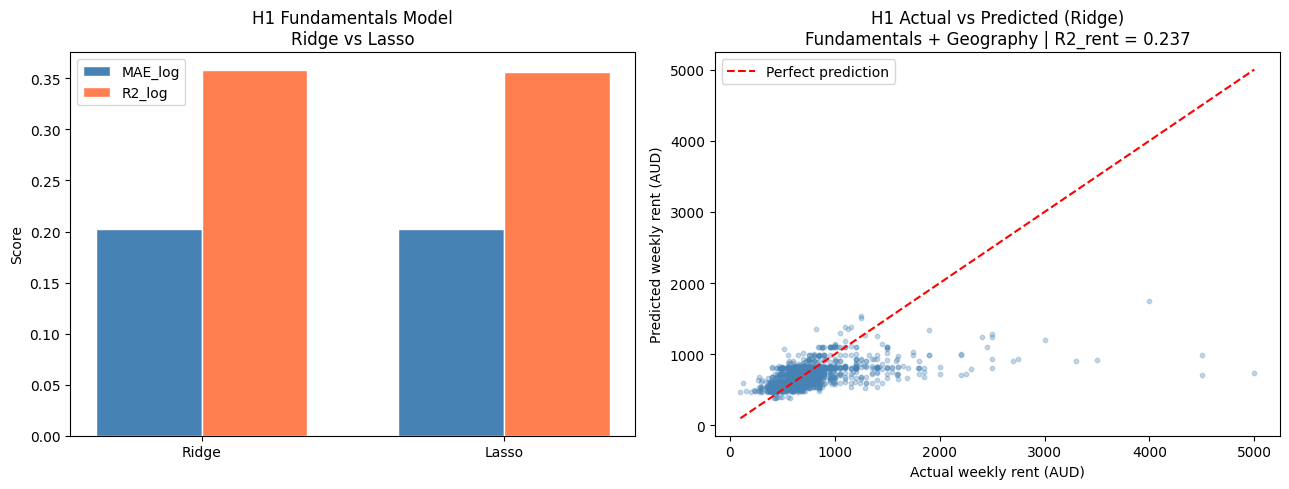

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Ridge vs Lasso
plot_df = results_df.set_index("model")

models = plot_df.index.tolist()
x = np.arange(len(models))
width = 0.35

axes[0].bar( x - width / 2, plot_df["MAE_log"], width, label="MAE_log", color="steelblue", edgecolor="white" )

axes[0].bar( x + width / 2, plot_df["R2_log"], width, label="R2_log", color="coral", edgecolor="white" )
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_title("H1 Fundamentals Model\nRidge vs Lasso")
axes[0].set_ylabel("Score")
axes[0].legend()

# Ridge performance
ridge_predictions = best_ridge_model.predict(X_test)

y_test_rent = np.expm1(y_test)
ridge_predictions_rent = np.expm1(ridge_predictions)

axes[1].scatter(y_test_rent, ridge_predictions_rent, alpha=0.3, color="steelblue", s=10)
axes[1].plot([y_test_rent.min(), y_test_rent.max()], [y_test_rent.min(), y_test_rent.max()],"r--", linewidth=1.5, label="Perfect prediction")

axes[1].set_title( "H1 Actual vs Predicted (Ridge)\n"
    f"Fundamentals + Geography | R2_rent = {ridge_r2_rent:.3f}")

axes[1].set_xlabel("Actual weekly rent (AUD)")
axes[1].set_ylabel("Predicted weekly rent (AUD)")
axes[1].legend()

plt.tight_layout()
plt.show()

### H1 Visualization Summary

The chart on the left shows that Ridge and Lasso perform almost identically when only the basic property features are used. This indicates that bedrooms, bathrooms, parking spaces, and property type contain useful predictive signal, but by themselves they explain only a limited share of the overall variation in rent.

The chart on the right shows that the Ridge model captures the general relationship between fundamentals and rent, but the predictions are compressed toward the middle of the rent distribution. Lower-rent listings are often predicted somewhat too high, while higher-rent listings are often predicted too low. This pattern suggests that important sources of variation, especially location and amenities, are still missing from the model.

### H2 Geography Adds Substantial Explanatory Power

State and postcode are added to test whether location explains rent variation beyond 
fundamentals. Postcode provides 1,093 neighborhood-level categories.


In [20]:
# Features now include fundamentals + geography (state, postcode, suburb)
X_geo = df[["bedrooms", "bathrooms", "parking_spaces", "propertyType",
            "state", "postcode", "suburb"]].copy()

# Convert categorical variables to dummy indicators
X_geo = pd.get_dummies(X_geo, columns=["propertyType", "state", "postcode", "suburb"])

# Recreate the same train/test split used in H1
X_train_geo, X_test_geo, y_train, y_test, state_train, state_test = train_test_split(
    X_geo, y, df["state"], random_state=1, stratify=df["state"])

print(f"Training rows: {len(X_train_geo)}")
print(f"Test rows: {len(X_test_geo)}")
print(f"Total features in H2: {X_geo.shape[1]}")

Training rows: 5067
Test rows: 1690
Total features in H2: 3109


In [21]:
# Features now include fundamentals + geography (state, postcode)
X_geo = df[["bedrooms", "bathrooms", "parking_spaces", "propertyType",
            "state", "postcode"]].copy()

# Convert categorical variables to dummy indicators
X_geo = pd.get_dummies(X_geo, columns=["propertyType", "state", "postcode"])

# Recreate the same train/test split used in H1
X_train_geo, X_test_geo, y_train, y_test, state_train, state_test = train_test_split(
    X_geo, y, df["state"], random_state=1, stratify=df["state"])

print(f"Training rows: {len(X_train_geo)}")
print(f"Test rows: {len(X_test_geo)}")
print(f"Total features in H2: {X_geo.shape[1]}")

results_geo = []

# Ridge regression
best_ridge_geo, best_ridge_alpha_geo, best_ridge_cv_mae_geo, ridge_mae_log_geo, ridge_r2_log_geo, ridge_mae_rent_geo, ridge_r2_rent_geo = fit_model_with_cv(
    "ridge", X_train_geo, y_train, X_test_geo, y_test, alpha_values, kf, state_train)

print(f"\nBest Ridge alpha (H2): {best_ridge_alpha_geo}\n")
results_geo.append(["Ridge", ridge_mae_log_geo, ridge_r2_log_geo, ridge_mae_rent_geo, ridge_r2_rent_geo])

# Lasso regression
best_lasso_geo, best_lasso_alpha_geo, best_lasso_cv_mae_geo, lasso_mae_log_geo, lasso_r2_log_geo, lasso_mae_rent_geo, lasso_r2_rent_geo = fit_model_with_cv(
    "lasso", X_train_geo, y_train, X_test_geo, y_test, alpha_values, kf, state_train)

print(f"\nBest Lasso alpha (H2): {best_lasso_alpha_geo}\n")
results_geo.append(["Lasso", lasso_mae_log_geo, lasso_r2_log_geo, lasso_mae_rent_geo, lasso_r2_rent_geo])

# Results table
results_h2_df = pd.DataFrame(results_geo, columns=["model", "MAE_log", "R2_log", "MAE_rent", "R2_rent"])
display(results_h2_df)

Training rows: 5067
Test rows: 1690
Total features in H2: 1114
Ridge alpha=0.001: CV MAE = 0.1334
Ridge alpha=0.01: CV MAE = 0.1333
Ridge alpha=0.1: CV MAE = 0.1324
Ridge alpha=1: CV MAE = 0.1325
Ridge alpha=10: CV MAE = 0.1563
Ridge alpha=100: CV MAE = 0.1785

Best Ridge alpha (H2): 0.1

Lasso alpha=0.001: CV MAE = 0.1792
Lasso alpha=0.01: CV MAE = 0.1916
Lasso alpha=0.1: CV MAE = 0.2371
Lasso alpha=1: CV MAE = 0.2538
Lasso alpha=10: CV MAE = 0.2538
Lasso alpha=100: CV MAE = 0.2538

Best Lasso alpha (H2): 0.001



,model,MAE_log,R2_log,MAE_rent,R2_rent
0,Ridge,0.138086,0.643514,115.564679,0.496778
1,Lasso,0.188489,0.442055,153.061483,0.311404


### H2 Results

Adding location produced the largest improvement in predictive performance in the modeling sequence. Ridge selected **alpha = 0.1** and achieved **R2_log = 0.644** and **MAE_rent = 115.56 AUD/week**, up from **0.358** in H1. Lasso performed worse at **R2_log = 0.442**, which is consistent with geographic information being distributed across many correlated postcode indicators rather than concentrated in a small subset.

This gap between Ridge and Lasso suggests that location is better represented as a broad set of correlated geographic features than as a sparse set of selected postcodes, which helps explain why Ridge performs better in this stage.

*Note: I also tested suburb in H2, but it reduced held-out performance and was removed from the final specification.*

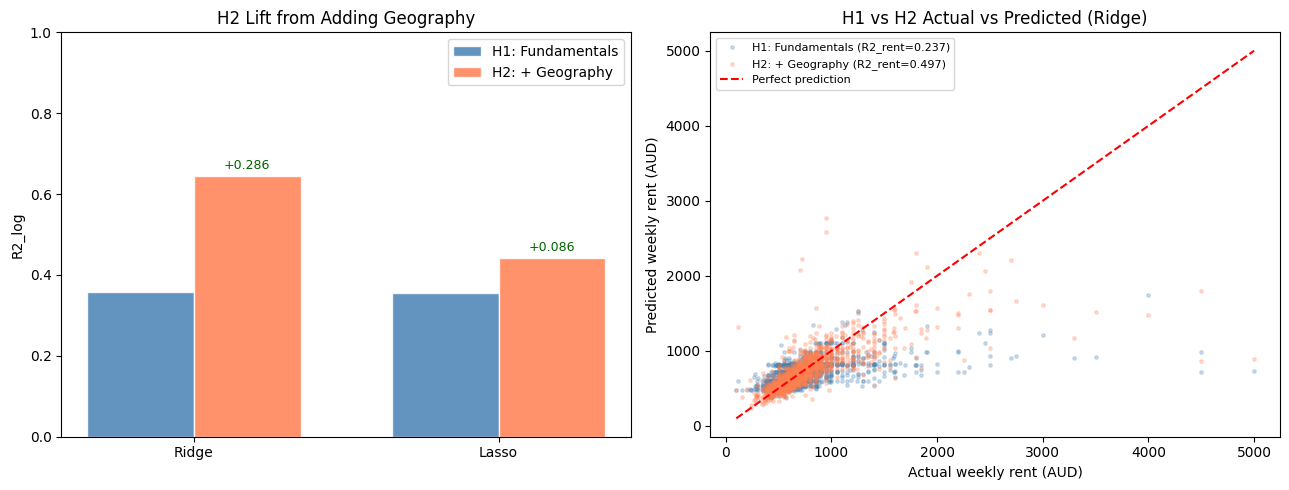

In [22]:
# --- Visualization: H1 vs H2 lift + actual vs predicted ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: H1 vs H2 R2 comparison
h1_r2 = results_df["R2_log"].values
h2_r2 = results_h2_df["R2_log"].values
models = ["Ridge", "Lasso"]
x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width / 2,h1_r2,width,label="H1: Fundamentals",
    color="steelblue",edgecolor="white",alpha=0.85)

axes[0].bar(x + width / 2,h2_r2,width,label="H2: + Geography",
            color="coral",edgecolor="white",alpha=0.85)

# Compute the improvement in R2 from H1 to H2
r2_lift = h2_r2 - h1_r2

# Add the improvement labels above the H2 bars
for i in range(len(r2_lift)):
    lift_value = r2_lift[i]
    x_position = x[i] + width / 2
    y_position = h2_r2[i] + 0.01
    label_text = f"+{lift_value:.3f}"
    axes[0].annotate(label_text,xy=(x_position, y_position),
        ha="center",va="bottom",fontsize=9,color="darkgreen")

axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_title("H2 Lift from Adding Geography")
axes[0].set_ylabel("R2_log")
axes[0].legend()
axes[0].set_ylim(0, 1)

# Right: H1 vs H2 actual vs predicted (Ridge)
ridge_h1_predictions = best_ridge_model.predict(X_test)
ridge_h2_predictions = best_ridge_geo.predict(X_test_geo)

y_test_rent = np.expm1(y_test)
ridge_h1_predictions_rent = np.expm1(ridge_h1_predictions)
ridge_h2_predictions_rent = np.expm1(ridge_h2_predictions)

axes[1].scatter(y_test_rent,ridge_h1_predictions_rent,
    alpha=0.25,color="steelblue",s=6,label=f"H1: Fundamentals (R2_rent={ridge_r2_rent:.3f})")

axes[1].scatter(y_test_rent,ridge_h2_predictions_rent,
    alpha=0.25,color="coral",s=6,label=f"H2: + Geography (R2_rent={ridge_r2_rent_geo:.3f})")

axes[1].plot([y_test_rent.min(), y_test_rent.max()],[y_test_rent.min(), y_test_rent.max()],
    "r--",linewidth=1.5,label="Perfect prediction")

axes[1].set_title("H1 vs H2 Actual vs Predicted (Ridge)")
axes[1].set_xlabel("Actual weekly rent (AUD)")
axes[1].set_ylabel("Predicted weekly rent (AUD)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### H2 Visualization Summary

Ridge R2_log increases from **0.358** in H1 to **0.644** in H2, the largest improvement in the modeling sequence. Lasso also improves, from **0.371** to **0.442**, though it still performs worse than Ridge. The scatter plot makes this visible: H2 predictions follow the diagonal more closely than H1, indicating that adding geography substantially improves predictive performance beyond the baseline model.

### H3: Amenities

Individual amenities are added to test whether they improve predictions beyond fundamentals and location. The amenities column is stored as comma-separated text, so each listing is split into individual features and converted to dummy variables.

Amenities are added after geography so their incremental contribution can be evaluated on top of the baseline model. I expect a modest improvement over H2 and for Lasso to be more competitive here, since only a subset of amenity indicators may add distinct predictive value once fundamentals and location are already included.

In [23]:
# Add amenity features

# Clean the amenities text before creating dummy columns
def clean_amenity_text(text):
    items = text.split(",")
    cleaned_items = []
    for item in items:
        item = item.strip().lower()
        if item != "":
            cleaned_items.append(item)
    return ",".join(cleaned_items)

clean_amenities = df["amenities"].apply(clean_amenity_text)

# Create dummy columns from the cleaned text
amenity_dummies = clean_amenities.str.get_dummies(sep=",")

# Drop blank amenity column
amenity_dummies = amenity_dummies.loc[:, amenity_dummies.columns != ""]

# Combine the amenity columns with the feature set from H2
X_h3 = pd.concat([X_geo.copy(), amenity_dummies], axis=1)

y = df["log_price"].copy()

X_train_h3, X_test_h3, y_train, y_test, state_train, state_test = train_test_split(
    X_h3, y, df["state"], random_state=1, stratify=df["state"])

print(f"Training rows: {len(X_train_h3)}")
print(f"Test rows: {len(X_test_h3)}")
print(f"Total features in H3: {X_h3.shape[1]}")
print("Duplicate amenity columns:", amenity_dummies.columns.duplicated().sum())

Training rows: 5067
Test rows: 1690
Total features in H3: 1194
Duplicate amenity columns: 0


In [24]:
results_h3 = []

# Ridge regression
best_ridge_h3, best_ridge_alpha_h3, best_ridge_cv_mae_h3, ridge_mae_log_h3, ridge_r2_log_h3, ridge_mae_rent_h3, ridge_r2_rent_h3 = fit_model_with_cv(
    "ridge", X_train_h3, y_train, X_test_h3, y_test, alpha_values, kf, state_train)

print(f"\nBest Ridge alpha (H3): {best_ridge_alpha_h3}\n")
results_h3.append(["Ridge", ridge_mae_log_h3, ridge_r2_log_h3, ridge_mae_rent_h3, ridge_r2_rent_h3])

# Lasso regression
best_lasso_h3, best_lasso_alpha_h3, best_lasso_cv_mae_h3, lasso_mae_log_h3, lasso_r2_log_h3, lasso_mae_rent_h3, lasso_r2_rent_h3 = fit_model_with_cv(
    "lasso", X_train_h3, y_train, X_test_h3, y_test, alpha_values, kf, state_train)

print(f"\nBest Lasso alpha (H3): {best_lasso_alpha_h3}\n")
results_h3.append(["Lasso", lasso_mae_log_h3, lasso_r2_log_h3, lasso_mae_rent_h3, lasso_r2_rent_h3])

# Results table
results_h3_df = pd.DataFrame(results_h3, columns=["model", "MAE_log", "R2_log", "MAE_rent", "R2_rent"])
display(results_h3_df)

Ridge alpha=0.001: CV MAE = 0.1314
Ridge alpha=0.01: CV MAE = 0.1313
Ridge alpha=0.1: CV MAE = 0.1302
Ridge alpha=1: CV MAE = 0.1308
Ridge alpha=10: CV MAE = 0.1533
Ridge alpha=100: CV MAE = 0.1735

Best Ridge alpha (H3): 0.1

Lasso alpha=0.001: CV MAE = 0.1744
Lasso alpha=0.01: CV MAE = 0.1905
Lasso alpha=0.1: CV MAE = 0.2371
Lasso alpha=1: CV MAE = 0.2538
Lasso alpha=10: CV MAE = 0.2538
Lasso alpha=100: CV MAE = 0.2538

Best Lasso alpha (H3): 0.001



,model,MAE_log,R2_log,MAE_rent,R2_rent
0,Ridge,0.134540,0.659676,112.506100,0.513132
1,Lasso,0.180997,0.476817,147.291463,0.344403


### H3 Results

Amenities add a modest improvement over H2. Ridge selected **alpha = 0.1** and achieved **R2_log = 0.660** and **MAE_rent = 112.51 AUD/week**, up from **0.644** in H2. Lasso improved to **R2_log = 0.477** but still performed worse than Ridge.

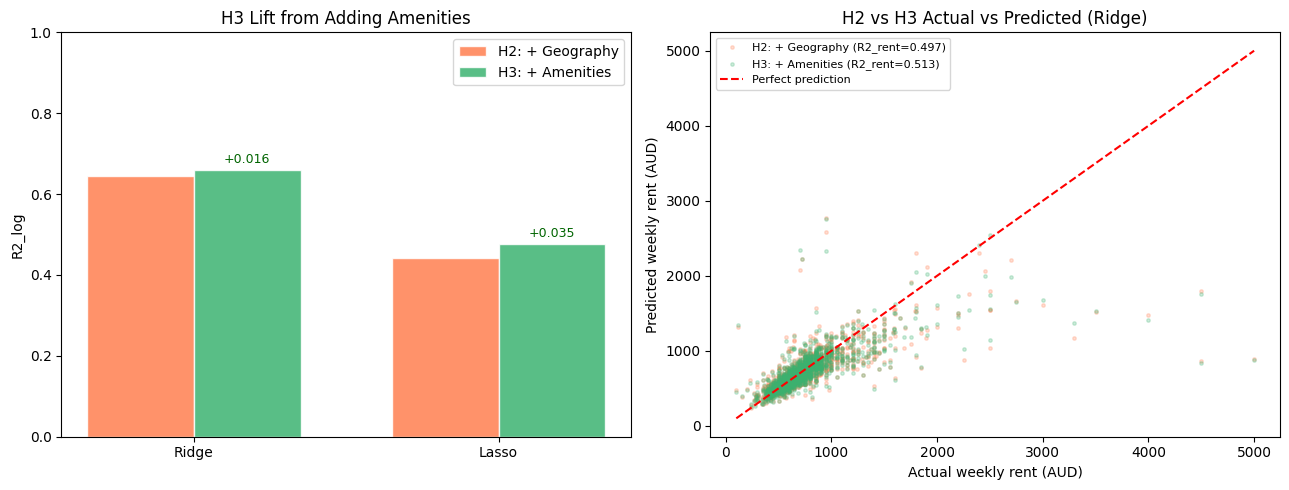

In [25]:
#H2 vs H3 lift + actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: H2 vs H3 R2 comparison
h2_r2 = results_h2_df["R2_log"].values
h3_r2 = results_h3_df["R2_log"].values
models = ["Ridge", "Lasso"]
x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width / 2,h2_r2,width,label="H2: + Geography",
    color="coral",edgecolor="white",alpha=0.85)

axes[0].bar(x + width / 2,h3_r2,width,label="H3: + Amenities",
            color="mediumseagreen",edgecolor="white",alpha=0.85)

# Compute the improvement in R2 from H2 to H3
r2_lift = h3_r2 - h2_r2

# Add the improvement labels above the H3 bars
for i in range(len(r2_lift)):
    lift_value = r2_lift[i]
    x_position = x[i] + width / 2
    y_position = h3_r2[i] + 0.01
    label_text = f"+{lift_value:.3f}"
    axes[0].annotate(label_text,xy=(x_position, y_position),
        ha="center",va="bottom",fontsize=9,color="darkgreen")

axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_title("H3 Lift from Adding Amenities")
axes[0].set_ylabel("R2_log")
axes[0].legend()
axes[0].set_ylim(0, 1)

# Right: H2 vs H3 actual vs predicted (Ridge)
ridge_h2_predictions = best_ridge_geo.predict(X_test_geo)
ridge_h3_predictions = best_ridge_h3.predict(X_test_h3)

y_test_rent = np.expm1(y_test)
ridge_h2_predictions_rent = np.expm1(ridge_h2_predictions)
ridge_h3_predictions_rent = np.expm1(ridge_h3_predictions)

axes[1].scatter(y_test_rent,ridge_h2_predictions_rent,
    alpha=0.25,color="coral",s=6,label=f"H2: + Geography (R2_rent={ridge_r2_rent_geo:.3f})")

axes[1].scatter(y_test_rent,ridge_h3_predictions_rent,
    alpha=0.25,color="mediumseagreen",s=6,label=f"H3: + Amenities (R2_rent={ridge_r2_rent_h3:.3f})")

axes[1].plot([y_test_rent.min(), y_test_rent.max()],[y_test_rent.min(), y_test_rent.max()],
    "r--",linewidth=1.5,label="Perfect prediction")

axes[1].set_title("H2 vs H3 Actual vs Predicted (Ridge)")
axes[1].set_xlabel("Actual weekly rent (AUD)")
axes[1].set_ylabel("Predicted weekly rent (AUD)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### H3 Visualization Summary

Amenities produce a modest improvement. Ridge R2_log increases from **0.644** to **0.660**, and the scatter plot shows a slight tightening around the diagonal. The main performance gains still come from location, with amenities providing a smaller refinement to the model.

### H4: Amenity Effects

H3 showed that amenities improve the model overall. H4 looks at which specific amenities are most strongly associated with that added signal. Lasso is used here rather than Ridge because it can shrink weaker amenity coefficients to zero, producing a more compact and interpretable set of retained features.

Coefficients are converted from log scale to approximate percentage changes in predicted rent using  
**100 × (e^β - 1)**, so a coefficient of **0.05** can be read as roughly a **5% higher predicted rent** under the fitted model. Positive coefficients indicate amenities associated with higher predicted rent, while negative coefficients indicate the opposite.

I expect premium features like pools and parking upgrades to show positive associations, while very common amenities may have coefficients closer to zero because they add less distinct predictive value.

In [26]:
# H4: Pull out the amenity coefficients from the H3 Lasso model

# Start with a table of all features and their coefficients
amenity_df = pd.DataFrame()
amenity_df["feature"] = X_train_h3.columns
amenity_df["coef_log"] = best_lasso_h3.coef_

# Remove the features that were already in H2
# That leaves only the amenity features
h2_features = list(X_geo.columns)

amenity_rows = []

for i in range(len(amenity_df)):
    feature_name = amenity_df.iloc[i]["feature"]
    
    if feature_name not in h2_features:
        amenity_rows.append(i)

amenity_df = amenity_df.iloc[amenity_rows].copy()

# Convert log coefficients to approximate percent change in predicted rent
amenity_df["pct_effect"] = (np.exp(amenity_df["coef_log"]) - 1) * 100

# Use the feature name as the amenity label
amenity_df["amenity"] = amenity_df["feature"]

# Separate into positive, negative, and zero coefficients
premium_rows = []
discount_rows = []
zero_rows = []

for i in range(len(amenity_df)):
    coef = amenity_df.iloc[i]["coef_log"]
    
    if coef > 0:
        premium_rows.append(i)
    elif coef < 0:
        discount_rows.append(i)
    else:
        zero_rows.append(i)

premium_amenities = amenity_df.iloc[premium_rows].sort_values(by="coef_log", ascending=False)
discount_amenities = amenity_df.iloc[discount_rows].sort_values(by="coef_log", ascending=True)
zeroed_amenities = amenity_df.iloc[zero_rows]

# Count how many amenities were kept and how many were shrunk to zero
retained_count = len(premium_amenities) + len(discount_amenities)
zeroed_count = len(zeroed_amenities)

print(f"Amenities retained by Lasso: {retained_count}")
print(f"Amenities zeroed out by Lasso: {zeroed_count}")

# Show the largest positive coefficients
print("\nTop positive amenity associations:")
display(premium_amenities[["amenity", "coef_log", "pct_effect"]].head(10).reset_index(drop=True))

# Show the largest negative coefficients
print("\nTop negative amenity associations:")
display(discount_amenities[["amenity", "coef_log", "pct_effect"]].head(10).reset_index(drop=True))

Amenities retained by Lasso: 25
Amenities zeroed out by Lasso: 55

Top positive amenity associations:


,amenity,coef_log,pct_effect
0,swimming pool - inground,0.118187,12.545442
1,deck,0.055550,5.712160
2,study,0.041781,4.266614
3,floorboards,0.039353,4.013778
4,furnished,0.036188,3.685034
5,balcony,0.035887,3.653898
6,ducted cooling,0.035131,3.575542
7,intercom,0.034360,3.495751
8,outdoor entertaining area,0.033975,3.455836
9,gym,0.024475,2.477717



Top negative amenity associations:


,amenity,coef_log,pct_effect
0,fully fenced,-0.051639,-5.032803
1,toilets: 2,-0.027879,-2.749386
2,air conditioning,-0.016148,-1.601877
3,ensuite: 1,-0.014546,-1.444029
4,toilets: 1,-0.013735,-1.364123
5,split-system air conditioning,-0.012627,-1.254765
6,evaporative cooling,-0.011612,-1.154511
7,secure parking,-0.005072,-0.505906
8,remote garage,-0.003009,-0.300442


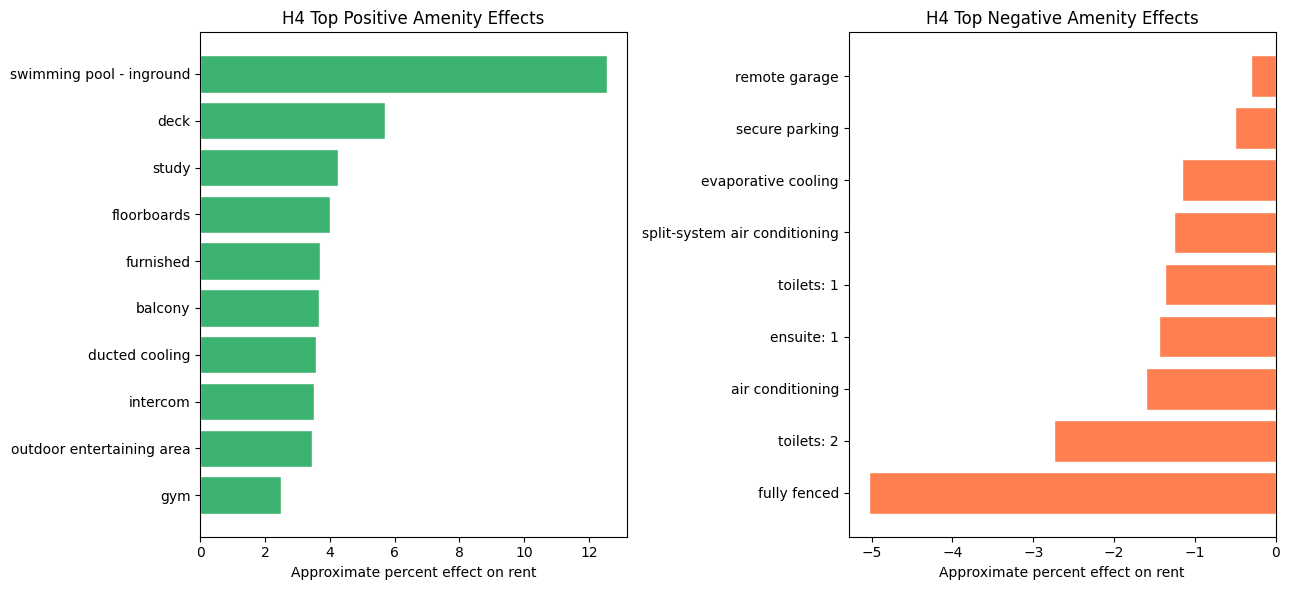

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Top positive amenity effects
top_positive = premium_amenities.head(10).copy()
top_positive = top_positive.sort_values(by="pct_effect", ascending=True)

axes[0].barh(top_positive["amenity"],top_positive["pct_effect"],
    color="mediumseagreen",edgecolor="white")

axes[0].set_title("H4 Top Positive Amenity Effects")
axes[0].set_xlabel("Approximate percent effect on rent")
axes[0].set_ylabel("")

# Top negative amenity effects
top_negative = discount_amenities.head(10).copy()
top_negative = top_negative.sort_values(by="pct_effect", ascending=True)

axes[1].barh(top_negative["amenity"],top_negative["pct_effect"],color="coral",edgecolor="white")

axes[1].set_title("H4 Top Negative Amenity Effects")
axes[1].set_xlabel("Approximate percent effect on rent")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### H4 Results

Lasso retained 25 amenities with nonzero coefficients and shrank 55 to zero, suggesting that many amenities add limited incremental predictive value once location and fundamentals are included in the model.

Among the retained amenities, inground swimming pools show the largest positive association at roughly **+12.5%** predicted rent, followed by decks **(+5.7%)**, studies **(+4.3%)**, and floorboards **(+4.0%)**. Furnished listings and balconies also show modest positive associations.

On the negative side, fully fenced **(−5.0%)** has the most negative coefficient, followed by toilets: 2 **(−2.7%)** and air conditioning **(−1.6%)**. These negative associations are less intuitive and should be interpreted cautiously. One possible explanation is that, after controlling for the modeled features, these amenities are more common in lower-priced suburban or regional listings than in higher-rent urban properties.

### H5: Amenity Richness Adjustment

H4 estimates associations for individual amenities, but listings can include many amenities at the same time. That makes it worth testing whether part of the signal comes from overall feature richness rather than any one feature by itself.

To examine this, `amenity_count` is added to the model to represent the total number of amenities listed for each property. This allows the model to separate two patterns: the overall association between amenity-rich listings and predicted rent, and the remaining associations for specific amenities after accounting for that general richness. Amenities that retain nonzero coefficients after adding `amenity_count` can be interpreted as features whose associations are not fully absorbed by overall amenity count.

In [28]:
# H5: Add a count of amenities to the H3 feature set

# Count how many amenities each listing has
amenity_count = []

for text in df["amenities"]:
    
    count = 0
    items = text.split(",")

    for item in items:
        item = item.strip()

        if item != "":
            count += 1

    amenity_count.append(count)

# Copy the H3 features and add the new amenity count column
X_h5 = X_h3.copy()
X_h5["amenity_count"] = amenity_count

# Split into training and test sets
X_train_h5, X_test_h5, y_train, y_test, state_train, state_test = train_test_split(
    X_h5, y, df["state"], random_state=1, stratify=df["state"]
)

print(f"Training rows: {len(X_train_h5)}")
print(f"Test rows: {len(X_test_h5)}")
print(f"Total features in H5: {X_h5.shape[1]}")

Training rows: 5067
Test rows: 1690
Total features in H5: 1195


In [29]:
results_h5 = []

# Ridge regression
best_ridge_h5, best_ridge_alpha_h5, best_ridge_cv_mae_h5, ridge_mae_log_h5, ridge_r2_log_h5, ridge_mae_rent_h5, ridge_r2_rent_h5 = fit_model_with_cv(
    "ridge", X_train_h5, y_train, X_test_h5, y_test, alpha_values, kf, state_train)

print(f"\nBest Ridge alpha (H5): {best_ridge_alpha_h5}\n")
results_h5.append(["Ridge", ridge_mae_log_h5, ridge_r2_log_h5, ridge_mae_rent_h5, ridge_r2_rent_h5])

# Lasso regression
best_lasso_h5, best_lasso_alpha_h5, best_lasso_cv_mae_h5, lasso_mae_log_h5, lasso_r2_log_h5, lasso_mae_rent_h5, lasso_r2_rent_h5 = fit_model_with_cv(
    "lasso", X_train_h5, y_train, X_test_h5, y_test, alpha_values, kf, state_train)

print(f"\nBest Lasso alpha (H5): {best_lasso_alpha_h5}\n")
results_h5.append(["Lasso", lasso_mae_log_h5, lasso_r2_log_h5, lasso_mae_rent_h5, lasso_r2_rent_h5])

# Results table
results_h5_df = pd.DataFrame(results_h5, columns=["model", "MAE_log", "R2_log", "MAE_rent", "R2_rent"])
display(results_h5_df)

Ridge alpha=0.001: CV MAE = 0.1315
Ridge alpha=0.01: CV MAE = 0.1313
Ridge alpha=0.1: CV MAE = 0.1302
Ridge alpha=1: CV MAE = 0.1308
Ridge alpha=10: CV MAE = 0.1532
Ridge alpha=100: CV MAE = 0.1734

Best Ridge alpha (H5): 0.1

Lasso alpha=0.001: CV MAE = 0.1744
Lasso alpha=0.01: CV MAE = 0.1904
Lasso alpha=0.1: CV MAE = 0.2331
Lasso alpha=1: CV MAE = 0.2538
Lasso alpha=10: CV MAE = 0.2538
Lasso alpha=100: CV MAE = 0.2538

Best Lasso alpha (H5): 0.001



,model,MAE_log,R2_log,MAE_rent,R2_rent
0,Ridge,0.134507,0.659872,112.488299,0.513319
1,Lasso,0.180593,0.478217,147.016699,0.345494


### H5 Results

Ridge selected **alpha = 0.1** and achieved **R2_log = 0.660** and **MAE_rent = 112.49 AUD/week**, essentially identical to H3. Adding `amenity_count` provides little additional predictive improvement on the held-out test set.

The more informative result is how the individual amenity coefficients change once `amenity_count` is included. Some of the broad amenity-richness signal appears to be captured by that variable, while the remaining amenity coefficients reflect associations not fully explained by overall amenity count. Amenities that shrink substantially or drop to zero in H5 may have been capturing broader listing richness in H4. Amenities that retain nonzero coefficients remain associated with predicted rent even after accounting for overall amenity count.

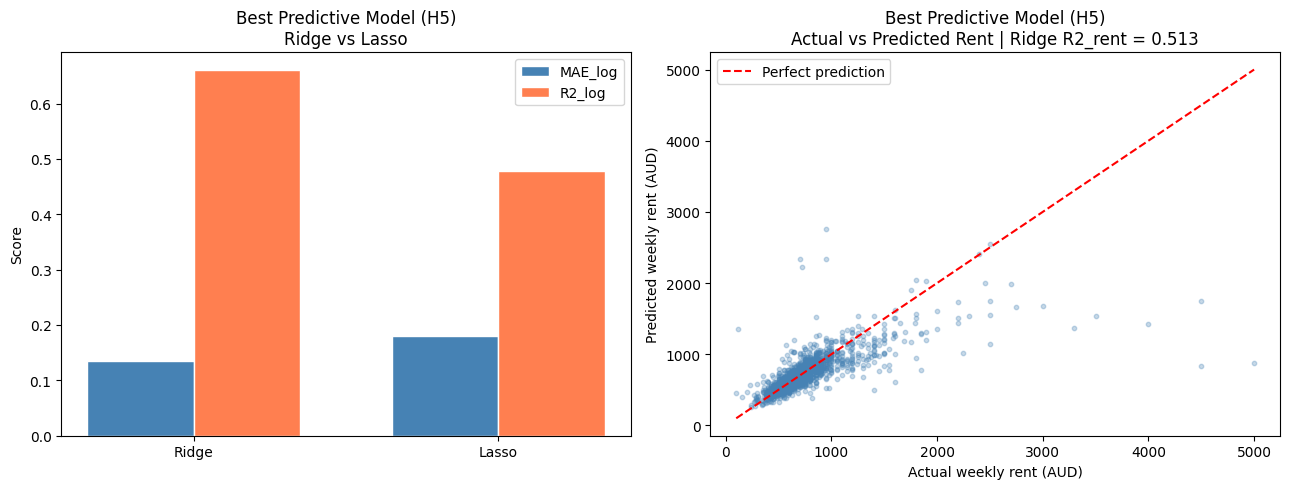

In [30]:
# Recreates plots from H1 for H5

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Ridge vs Lasso
plot_df = results_h5_df.set_index("model")

models = plot_df.index.tolist()
x = np.arange(len(models))
width = 0.35

axes[0].bar( x - width / 2, plot_df["MAE_log"], width, label="MAE_log", color="steelblue", edgecolor="white" )

axes[0].bar( x + width / 2, plot_df["R2_log"], width, label="R2_log", color="coral", edgecolor="white" )
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_title("Best Predictive Model (H5)\nRidge vs Lasso")
axes[0].set_ylabel("Score")
axes[0].legend()

# Ridge performance
ridge_h5_predictions = best_ridge_h5.predict(X_test_h5)

y_test_rent = np.expm1(y_test)
ridge_h5_predictions_rent = np.expm1(ridge_h5_predictions)

axes[1].scatter(y_test_rent, ridge_h5_predictions_rent, alpha=0.3, color="steelblue", s=10)
axes[1].plot([y_test_rent.min(), y_test_rent.max()], [y_test_rent.min(), y_test_rent.max()],"r--", linewidth=1.5, label="Perfect prediction")

axes[1].set_title( "Best Predictive Model (H5)\n"
    f"Actual vs Predicted Rent | Ridge R2_rent = {ridge_r2_rent_h5:.3f}")

axes[1].set_xlabel("Actual weekly rent (AUD)")
axes[1].set_ylabel("Predicted weekly rent (AUD)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [31]:
# H5: Pull out the amenity_count coefficient and compare H5 amenity coefficients to H4

# Keep a copy of the H4 amenity table for comparison
amenity_df_h4 = amenity_df.copy()

# Start with a table of all H5 features and their coefficients
coef_df_h5 = pd.DataFrame()
coef_df_h5["feature"] = X_train_h5.columns
coef_df_h5["coef_log_h5"] = best_lasso_h5.coef_

# Convert H5 log coefficients to approximate percent change in predicted rent
coef_df_h5["pct_effect_h5"] = (np.exp(coef_df_h5["coef_log_h5"]) - 1) * 100

# Pull out the amenity_count row
amenity_count_rows = []

for i in range(len(coef_df_h5)):
    feature_name = coef_df_h5.iloc[i]["feature"]
    
    if feature_name == "amenity_count":
        amenity_count_rows.append(i)

amenity_count_row = coef_df_h5.iloc[amenity_count_rows].copy()

print("Amenity count effect:")
display(
    amenity_count_row[["feature", "coef_log_h5", "pct_effect_h5"]]
    .reset_index(drop=True)
)

# Keep only the amenity rows from H5
# Remove the H2 features and also remove amenity_count itself
h2_features = list(X_geo.columns)

amenity_rows_h5 = []

for i in range(len(coef_df_h5)):
    feature_name = coef_df_h5.iloc[i]["feature"]
    
    if feature_name not in h2_features and feature_name != "amenity_count":
        amenity_rows_h5.append(i)

amenity_df_h5 = coef_df_h5.iloc[amenity_rows_h5].copy()
amenity_df_h5["amenity"] = amenity_df_h5["feature"]

# Bring in the H4 percent effects for side-by-side comparison
h4_compare = amenity_df_h4[["amenity", "pct_effect"]].copy()
h4_compare = h4_compare.rename(columns={"pct_effect": "pct_effect_h4"})

amenity_compare = pd.merge(amenity_df_h5, h4_compare, on="amenity", how="left")

# Compute the change from H4 to H5
amenity_compare["delta"] = amenity_compare["pct_effect_h5"] - amenity_compare["pct_effect_h4"]

# Split into positive, negative, and zero H5 coefficients
positive_rows_h5 = []
negative_rows_h5 = []
zero_rows_h5 = []

for i in range(len(amenity_compare)):
    coef = amenity_compare.iloc[i]["coef_log_h5"]
    
    if coef > 0:
        positive_rows_h5.append(i)
    elif coef < 0:
        negative_rows_h5.append(i)
    else:
        zero_rows_h5.append(i)

positive_amenities_h5 = amenity_compare.iloc[positive_rows_h5].sort_values(
    by="coef_log_h5", ascending=False
)

negative_amenities_h5 = amenity_compare.iloc[negative_rows_h5].sort_values(
    by="coef_log_h5", ascending=True
)

zero_amenities_h5 = amenity_compare.iloc[zero_rows_h5]

# Count how many amenities were kept and how many were shrunk to zero
retained_count_h5 = len(positive_amenities_h5) + len(negative_amenities_h5)
zeroed_count_h5 = len(zero_amenities_h5)

print(f"\nAmenities retained by Lasso after adding amenity_count: {retained_count_h5}")
print(f"Amenities zeroed out by Lasso after adding amenity_count: {zeroed_count_h5}")

# Show the top positive H5 coefficients with H4 comparison
print("\nTop positive amenity associations:")
display(
    positive_amenities_h5[["amenity", "pct_effect_h4", "pct_effect_h5", "delta"]]
    .head(10)
    .reset_index(drop=True)
)

# Show the top negative H5 coefficients with H4 comparison
print("\nTop negative amenity associations:")
display(
    negative_amenities_h5[["amenity", "pct_effect_h4", "pct_effect_h5", "delta"]]
    .head(10)
    .reset_index(drop=True)
)

Amenity count effect:


,feature,coef_log_h5,pct_effect_h5
0,amenity_count,0.008701,0.873935



Amenities retained by Lasso after adding amenity_count: 28
Amenities zeroed out by Lasso after adding amenity_count: 52

Top positive amenity associations:


,amenity,pct_effect_h4,pct_effect_h5,delta
0,swimming pool - inground,12.545442,11.622196,-0.923246
1,deck,5.712160,4.674443,-1.037717
2,floorboards,4.013778,3.035046,-0.978732
3,study,4.266614,3.019313,-1.247301
4,furnished,3.685034,2.812922,-0.872112
5,balcony,3.653898,2.634071,-1.019827
6,intercom,3.495751,2.482356,-1.013395
7,outdoor entertaining area,3.455836,2.398489,-1.057347
8,ducted cooling,3.575542,1.767690,-1.807852
9,courtyard,2.254887,1.304109,-0.950778



Top negative amenity associations:


,amenity,pct_effect_h4,pct_effect_h5,delta
0,fully fenced,-5.032803,-6.169301,-1.136498
1,toilets: 2,-2.749386,-3.747525,-0.998139
2,split-system air conditioning,-1.254765,-2.641822,-1.387057
3,air conditioning,-1.601877,-2.559569,-0.957691
4,toilets: 1,-1.364123,-2.526510,-1.162387
5,evaporative cooling,-1.154511,-2.493044,-1.338532
6,ensuite: 1,-1.444029,-2.476690,-1.032661
7,secure parking,-0.505906,-1.578914,-1.073008
8,remote garage,-0.300442,-1.498934,-1.198492
9,broadband internet available,0.000000,-0.804901,-0.804901


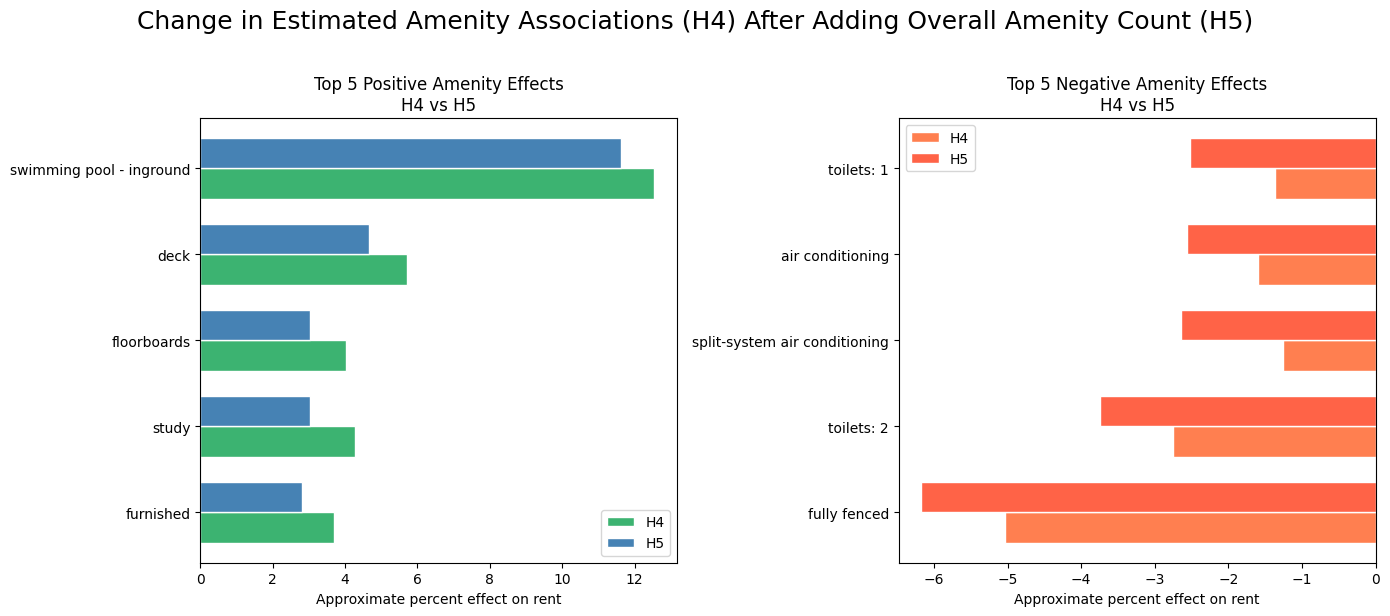

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plt.suptitle('Change in Estimated Amenity Associations (H4) After Adding Overall Amenity Count (H5)',fontsize=18,y=1.02)

# Top 5 positive amenities: H4 vs H5
top_positive_compare = positive_amenities_h5.head(5).copy()
top_positive_compare = top_positive_compare.sort_values(by="pct_effect_h5", ascending=True)
y_pos = np.arange(len(top_positive_compare))
bar_height = 0.35

axes[0].barh(y_pos - bar_height / 2,top_positive_compare["pct_effect_h4"],height=bar_height,
    color="mediumseagreen",edgecolor="white",label="H4")

axes[0].barh(y_pos + bar_height / 2,top_positive_compare["pct_effect_h5"],
    height=bar_height,color="steelblue",edgecolor="white",label="H5")
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(top_positive_compare["amenity"])
axes[0].set_title("Top 5 Positive Amenity Effects\nH4 vs H5")
axes[0].set_xlabel("Approximate percent effect on rent")
axes[0].set_ylabel("")
axes[0].legend()

# Top 5 negative amenities: H4 vs H5
top_negative_compare = negative_amenities_h5.head(5).copy()
top_negative_compare = top_negative_compare.sort_values(by="pct_effect_h5", ascending=True)

y_neg = np.arange(len(top_negative_compare))

axes[1].barh(y_neg - bar_height / 2,top_negative_compare["pct_effect_h4"],
    height=bar_height,color="coral",edgecolor="white",label="H4")
axes[1].barh(y_neg + bar_height / 2,top_negative_compare["pct_effect_h5"],
    height=bar_height,color="tomato",edgecolor="white",label="H5")
axes[1].set_yticks(y_neg)
axes[1].set_yticklabels(top_negative_compare["amenity"])
axes[1].set_title("Top 5 Negative Amenity Effects\nH4 vs H5")
axes[1].set_xlabel("Approximate percent effect on rent")
axes[1].set_ylabel("")
axes[1].legend()

plt.tight_layout()
plt.show()

### H5 Summary

Adding `amenity_count` introduces an overall amenity-richness term of about **+0.87% per additional listed amenity** in the fitted model. Once that variable is included, some of the signal previously assigned to individual amenities shifts to overall amenity count, so the remaining amenity coefficients reflect associations not fully explained by general feature richness.

A general pattern emerges: many positive coefficients become smaller, while some negative coefficients become more negative. Features like pools and decks remain positively associated with predicted rent after adding `amenity_count`, while features like fully fenced and split-system air conditioning become more negative in the fitted model.

Overall amenity richness is associated with higher-rent listings, and `amenity_count` is included to capture that broad pattern. After adding it to the model, the remaining amenity coefficients reflect each feature’s association with rent beyond general listing richness. This tends to reduce positive coefficients and make several negative coefficients more negative, suggesting that part of the H4 signal was capturing overall feature richness rather than only the contribution of specific amenities. Because the model is fit to log rent and is less accurate in the upper tail of the market, these coefficients should be interpreted cautiously, especially for expensive rental listings.

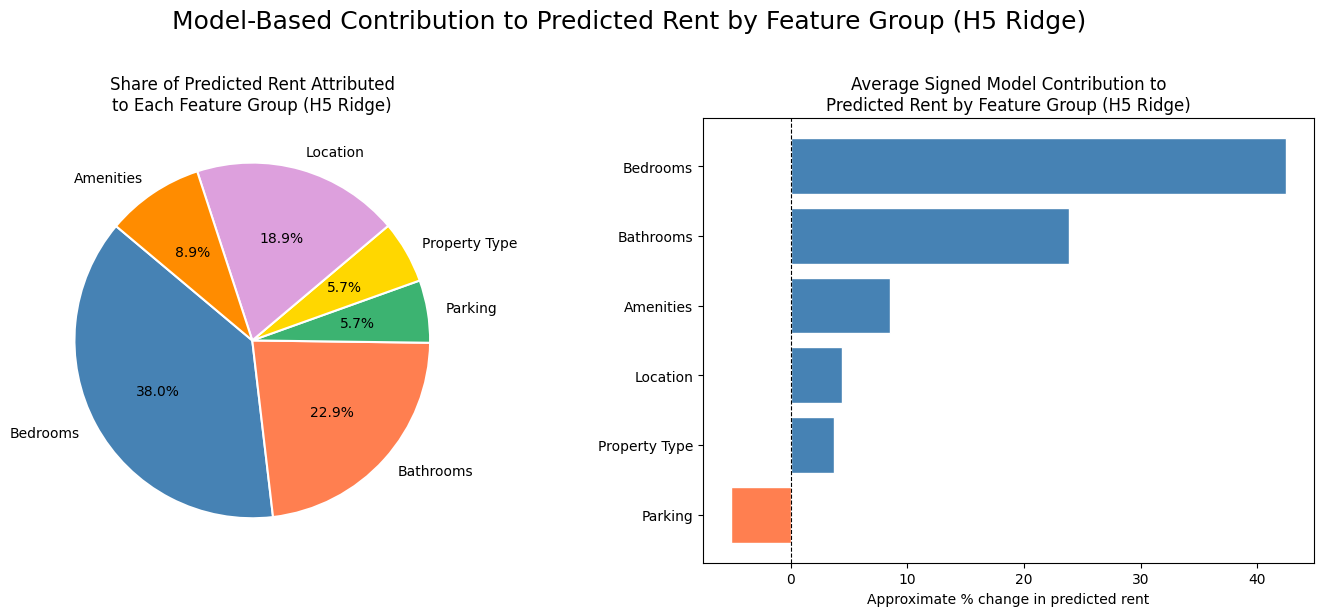

In [33]:
# Get the coefficients from the H5 Ridge model as a labeled Series
# This pairs each coefficient with its feature name
coefs = pd.Series(best_ridge_h5.coef_, index=X_train_h5.columns)

# Multiply each feature value by its coefficient for every listing in the test set
# The result is a table of the same shape as X_test_h5, but instead of raw feature
# values, each cell contains how much that feature contributed to the predicted rent
contributions = X_test_h5.copy() * coefs

# Assign each feature to a group
# We'll use this to sum up contributions by group later
feature_groups = {}
for col in X_test_h5.columns:
    if col == 'bedrooms':
        feature_groups[col] = 'Bedrooms'
    elif col == 'bathrooms':
        feature_groups[col] = 'Bathrooms'
    elif col == 'parking_spaces':
        feature_groups[col] = 'Parking'
    elif col.startswith('propertyType_'):
        feature_groups[col] = 'Property Type'
    elif col.startswith('state_') or col.startswith('postcode_'):
        feature_groups[col] = 'Location'
    elif col == 'amenity_count':
        feature_groups[col] = 'Amenities'
    else:
        feature_groups[col] = 'Amenities'

# Get the unique group names
groups = ['Bedrooms', 'Bathrooms', 'Parking', 'Property Type', 'Location', 'Amenities']

# For each group, find all features belonging to it and sum their contributions
# This gives us one column per group showing the total contribution for each listing
group_contributions = pd.DataFrame()
for group in groups:
    # Find all features belonging to this group
    group_features = [col for col in X_test_h5.columns if feature_groups[col] == group]
    # Sum contributions across all features in the group for each listing
    group_contributions[group] = contributions[group_features].sum(axis=1)

# Compute the average absolute contribution per group across all listings
# Absolute value is used so that positive and negative contributions
# within a group don't cancel each other out
mean_abs = group_contributions.abs().mean()

# Compute the average signed contribution per group
# This shows direction: positive means the group pushes rent up on average
mean_signed = group_contributions.mean().sort_values()

# Convert average signed contribution from log(rent) to approximate percent change in predicted rent
mean_signed_pct = 100 * (np.exp(mean_signed) - 1)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['steelblue', 'coral', 'mediumseagreen', 'gold', 'plum', 'darkorange']

# Pie chart: share of total explained variation by group (intercept excluded)
axes[0].pie(
    mean_abs,
    labels=mean_abs.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Share of Predicted Rent Attributed\nto Each Feature Group (H5 Ridge)')

# Bar chart: average signed contribution by group
# Coral = negative contribution, steelblue = positive
bar_colors = ['coral' if v < 0 else 'steelblue' for v in mean_signed_pct]
axes[1].barh(mean_signed_pct.index, mean_signed_pct.values, color=bar_colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Average Signed Model Contribution to\nPredicted Rent by Feature Group (H5 Ridge)')
axes[1].set_xlabel('Approximate % change in predicted rent')

plt.suptitle('Model-Based Contribution to Predicted Rent by Feature Group (H5 Ridge)', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

### H5 Visualization: Model-Based Contribution by Feature Group

To summarize the relative contribution of each feature group, I decomposed the H5 Ridge model predictions into components. For each listing in the test set, each feature’s contribution is calculated as its value multiplied by its coefficient. Contributions are then summed by group (Bedrooms, Bathrooms, Parking, Property Type, Location, Amenities) and averaged across all listings. The pie chart shows each group’s share of the total absolute model contribution, while the bar chart shows the average signed contribution to predicted rent. Positive values indicate a group is associated with higher predicted rent on average, while negative values indicate the opposite.

A clear pattern emerges from this decomposition. Bedrooms receive the largest share of absolute model contribution at **38%**, followed by Bathrooms at **23%**. Location is assigned **19%** in this decomposition despite being represented by more than 1,000 postcode indicators, which is consistent with regularization spreading geographic contribution across many smaller coefficients. Amenities account for **9%**, while Parking and Property Type each contribute about **6%**.

The bar chart adds one useful nuance: Parking has a slightly negative average signed contribution in the fitted model. One possible explanation is that higher-parking listings are more common in lower-rent suburban or regional markets, so after accounting for the other modeled features, parking contributes negatively on average in this decomposition.

# 7. Conclusions and Summary of Findings

This analysis examined the Australian Rental Market Data 2026 dataset to understand which listing features are most closely associated with weekly rent, building the model incrementally and evaluating each stage on a held-out test set.

### The Incremental Model Story

| Stage | R2_log | MAE_log | R2_rent | MAE_rent | Key Finding |
|---|---:|---:|---:|---:|---|
| H1: Fundamentals | 0.358 | 0.202 | 0.237 | 162.92 | Property size explains some rent variation but the model is limited without location. |
| H2: + Geography | 0.644 | 0.138 | 0.497 | 115.56 | Location adds the largest improvement in predictive performance. |
| H3: + Amenities | 0.660 | 0.135 | 0.513 | 112.51 | Amenities add a modest but consistent improvement beyond fundamentals and geography. |
| H5: + Amenity Richness | 0.660 | 0.135 | 0.513 | 112.49 | Amenity count captures a general richness association; individual coefficients shrink but persist. |

The jump from H1 to H2 is the clearest result in the project. Location adds substantially more predictive value than physical characteristics alone, and that gap remains even after additional features are added to the model.

### Final Model Performance

The final H5 Ridge model includes property fundamentals, geographic indicators, individual amenity dummies, and overall amenity richness. It achieves:

- **R2_log = 0.660**, explaining about 66% of the variation in log weekly rent
- **MAE_rent = 112.49 AUD/week**, meaning predictions are off by about 112 AUD/week on average

Because the model is optimized on log-transformed rent, it fits the mid-market well but underpredicts the highest-rent listings. This is a known tradeoff when modeling skewed price data.

### Contribution of Amenities

Amenities contribute in two ways. First, each additional listed amenity is associated with roughly **+0.87% predicted rent**, capturing a general richness pattern for feature-rich listings. Second, some specific amenities retain nonzero coefficients even after controlling for that general richness:

| Amenity | H4 Effect | H5 Effect |
|---|---|---|
| Inground swimming pool | +12.5% | +11.6% |
| Deck | +5.7% | +4.7% |
| Balcony | +3.7% | +2.6% |

The reduction from H4 to H5 suggests that part of the original association was reflecting listing richness rather than those specific features alone. Amenities that become more negative in H5, such as fully fenced and split-system air conditioning, may be more common in lower-priced suburban properties and appear weaker once the richness term is included.

### Central Finding

Three broad patterns emerge from the model:

1. **Location adds the largest predictive lift.** Where a property is located contributes more predictive value than any other feature group in this model.
2. **Property size adds meaningful signal.** Bedrooms and bathrooms explain a substantial share of variation, though some of that overlaps with location.
3. **Amenities contribute modestly.** The general richness term is small, and most individual amenity coefficients are modest once location is controlled for. Pools and decks are among the clearest positive associations.

### Limitations

- **Postcode dummies are effective but not interpretable.** Over 1,000 indicators make it hard to describe the geographic effect clearly. Spatial clustering would be a cleaner approach.
- **Associations, not causes.** A positive amenity coefficient does not mean adding that amenity would increase rent. The dataset is cross-sectional and causal claims are not warranted.
- **Self-reported amenity data.** Amenity listings may be incomplete or inconsistently labeled across properties, which could bias individual amenity estimates.

## 8. Next Steps

### Geographic Clustering to Replace Postcode and State Dummies

**What:** Replace both the 1,093 postcode dummy variables and the 8 state dummy variables 
with a smaller set of geographic clusters derived from latitude and longitude using K-means++. 
Each property would be assigned to a numbered cluster, which is then one-hot encoded as a 
dummy variable.

**Why it adds value:** The current approach introduces over 1,000 postcode dummies, many 
representing only a handful of listings, plus 8 state dummies that partially overlap with 
postcode information. Clustering into 20-50 geographic buckets replaces both with a single 
clean set of location indicators, reduces the feature space dramatically, improves 
generalization, and likely improves predictive performance.

**Level of effort: Low for the model, moderate/high for the visualization.**

The clustering itself is straightforward:

1. Fit KMeans (sklearn) on the latitude and longitude columns
2. Assign each listing a cluster number
3. One-hot encode the cluster column into dummy variables
4. Rerun the H2 model replacing both postcode and state with cluster dummies
5. Compare R2_log directly against the postcode/state baseline

The heatmap visualization requires additional work. Plotting cluster boundaries or 
centroids on a map of Australia requires a mapping library such as folium or geopanda,

### Residual Language Analysis Using TF-IDF

**What:** Apply TF-IDF (Term Frequency - Inverse Document Frequency) to the listing 
description text and compute an impact score for each word based on model residuals, 
the difference between actual and predicted rent. Words with high positive impact scores 
appear prominently in listings that rent for more than the model expects; words with high 
negative impact scores appear in listings that rent for less.

**Why it adds value:** The current model explains rent using structured features,
bedrooms, location, and amenities. Listing descriptions contain unstructured signals the 
model cannot see: prestige language, emotional appeal, and quality indicators like 
"renovated" or "oceanfront." This analysis would quantify the value of listing language 
after controlling for everything the structured model already captures, which is directly 
relevant to questions of information asymmetry in rental markets.

**Level of effort: Low to moderate.**

The analysis itself is low effort:
1. Retain the description column before cleaning, preserving the index for rejoining
2. Fit TF-IDF on listing descriptions using sklearn's TfidfVectorizer
3. Compute residuals from the final H5 model
4. Compute an impact score for each word as sum(weight^2 × residual) across all listings
5. Rank words by positive and negative impact score

**On the choice of impact scoring:** several approaches were considered. Weight × mean 
residual is intuitive but sensitive to outlier listings where a single high-residual 
property inflates the score. Weight × sum counters the IDF component of TF-IDF, 
effectively rewarding common words twice. Weight^2 × sum is the strongest choice, 
squaring the TF-IDF weight favors words that appear with high distinctiveness in 
specific listings and aggressively penalizes low-weight noise, analogous to the way 
L2 regularization in Ridge regression suppresses small coefficients while retaining 
large ones.

**Visualization: Low effort.** A word cloud colored by impact direction, warm colors 
for premium language, cool colors for discount language, can be generated with the 
wordcloud library in a few lines and would be immediately legible to a non-technical 
audience.

### Nonlinear Amenity Sensitivity Check

**What:** Fit a nonlinear model better suited to raw rent and the upper tail of the 
distribution, then test selected amenities by rescoring the test set after toggling them 
on and off. For listings that do not have a selected amenity, add it and measure the 
change in predicted rent. For listings that do have it, remove it and measure the drop. 
This produces a model-based sensitivity check for amenities across the existing test data.

**Why it adds value:** The current log-linear model is interpretable, but it underfits 
higher-rent listings and may miss nonlinear effects or interactions between amenities, 
location, and property type. A nonlinear model would provide a better check on whether the 
amenity signals seen in H4 and H5 remain directionally consistent once the model is allowed 
to fit high-end listings and more complex relationships more flexibly.

**Level of effort: Low to moderate.**

The analysis itself is manageable:
1. Fit a nonlinear model such as XGBoost or Random Forest on the same cleaned feature set
2. Score the original test set to generate baseline predicted rents
3. Select a small set of amenities with the strongest positive and negative associations
4. For each selected amenity, create modified copies of the test set where the amenity is added to listings that do not have it and removed from listings that do
5. Rescore the modified test sets and measure the change in predicted rent
6. Summarize the results overall and by rent segment to compare lower-, mid-, and higher-rent listings

**On the choice of sensitivity testing:** the goal is not causal inference. Toggling an 
amenity does not estimate the true market effect of adding that feature in reality. Instead, 
it provides a model-based check on how sensitive predicted rent is to selected amenities 
under a more flexible specification. This is especially useful because the current model is 
fit on log rent and performs less well in the upper tail, where amenity signal may differ.

**Visualization: Moderate effort.** The cleanest output would be a grouped bar chart or 
slope chart showing the average predicted change in rent when a selected amenity is added 
or removed, broken out by rent tier. This would make it easy to compare whether amenities 
behave differently in lower- and higher-rent segments.
